In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q librosa soundfile openai-whisper joblib tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 13.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 6.0 MB/s eta 0:00:00


In [4]:
import os
import json
import cv2
import math
import joblib
import librosa
import random
import warnings
import subprocess
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"

RAW_DIR = os.path.join(PROJECT_DIR, "data/raw/dfdc_train_part_00")
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")

CSV_DIR = os.path.join(PROCESSED_DIR, "csv")
FRAMES_DIR = os.path.join(PROCESSED_DIR, "frames")
AUDIO_DIR = os.path.join(PROCESSED_DIR, "audio")
TEXT_DIR = os.path.join(PROCESSED_DIR, "text")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "data/outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
GRAPH_DIR = os.path.join(OUTPUT_DIR, "graphs")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")
PRED_DIR = os.path.join(OUTPUT_DIR, "predictions")
EXPLAIN_DIR = os.path.join(OUTPUT_DIR, "explainability")
UNCERTAIN_DIR = os.path.join(OUTPUT_DIR, "uncertain_samples")

for folder in [
    CSV_DIR, FRAMES_DIR, AUDIO_DIR, TEXT_DIR,
    MODEL_DIR, GRAPH_DIR, REPORT_DIR, PRED_DIR,
    EXPLAIN_DIR, UNCERTAIN_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("All folders are ready.")

All folders are ready.


In [5]:
metadata_path = os.path.join(RAW_DIR, "metadata.json")

with open(metadata_path, "r") as f:
    metadata = json.load(f)

records = []

for filename, info in metadata.items():
    video_path = os.path.join(RAW_DIR, filename)

    if os.path.exists(video_path):
        label = info["label"]  # REAL or FAKE
        target = 0 if label == "FAKE" else 1

        records.append({
            "filename": filename,
            "video_path": video_path,
            "label": label,
            "target": target,
            "original": info.get("original", None)
        })

df = pd.DataFrame(records)
df.to_csv(os.path.join(CSV_DIR, "dfdc_metadata.csv"), index=False)

print("Total videos found:", len(df))
print(df["label"].value_counts())
df.head()

Total videos found: 1334
label
FAKE    1248
REAL      86
Name: count, dtype: int64


,filename,video_path,label,target,original
0,owxbbpjpch.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,FAKE,0,wynotylpnm.mp4
1,vpmyeepbep.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,REAL,1,None
2,fzvpbrzssi.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,REAL,1,None
3,htorvhbcae.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,FAKE,0,wclvkepakb.mp4
4,fckxaqjbxk.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,FAKE,0,vpmyeepbep.mp4


In [6]:
SAMPLE_PER_CLASS = 80  # change to 300, 500, 1000 later

df_sample = (
    df.groupby("target", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), SAMPLE_PER_CLASS), random_state=42))
    .reset_index(drop=True)
)

train_df, test_df = train_test_split(
    df_sample,
    test_size=0.2,
    random_state=42,
    stratify=df_sample["target"]
)

train_df.to_csv(os.path.join(CSV_DIR, "train.csv"), index=False)
test_df.to_csv(os.path.join(CSV_DIR, "test.csv"), index=False)

print("Train size:", len(train_df))
print("Test size:", len(test_df))
print("Train labels:")
print(train_df["label"].value_counts())
print("Test labels:")
print(test_df["label"].value_counts())

Train size: 128
Test size: 32
Train labels:
label
FAKE    64
REAL    64
Name: count, dtype: int64
Test labels:
label
REAL    16
FAKE    16
Name: count, dtype: int64


In [7]:
NUM_FRAMES = 5  # Reduced from 10 to 5 to mitigate potential memory issues

def extract_frames(video_path, output_folder, num_frames=5):
    os.makedirs(output_folder, exist_ok=True)

    existing_frames = list(Path(output_folder).glob("*.jpg"))
    if len(existing_frames) >= num_frames:
        return True

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return False

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return False

    frame_indices = np.linspace(0, total_frames - 1, num_frames).astype(int)

    saved = 0

    for idx, frame_no in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
        ret, frame = cap.read()

        if ret:
            frame = cv2.resize(frame, (224, 224))
            frame_path = os.path.join(output_folder, f"frame_{idx:03d}.jpg")
            cv2.imwrite(frame_path, frame)
            saved += 1

    cap.release()
    return saved > 0


all_df = pd.concat([train_df, test_df]).reset_index(drop=True)

for _, row in tqdm(all_df.iterrows(), total=len(all_df)):
    video_id = Path(row["filename"]).stem
    output_folder = os.path.join(FRAMES_DIR, video_id)
    extract_frames(row["video_path"], output_folder, NUM_FRAMES)

print("Frame extraction completed.")

100%|██████████| 160/160 [00:12<00:00, 13.24it/s]

Frame extraction completed.


In [8]:
def extract_audio(video_path, audio_path):
    if os.path.exists(audio_path):
        return True

    command = [
        "ffmpeg", "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", "16000",
        audio_path
    ]

    try:
        subprocess.run(
            command,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            timeout=60
        )
        return os.path.exists(audio_path)
    except:
        return False


for _, row in tqdm(all_df.iterrows(), total=len(all_df)):
    video_id = Path(row["filename"]).stem
    audio_path = os.path.join(AUDIO_DIR, f"{video_id}.wav")
    extract_audio(row["video_path"], audio_path)

print("Audio extraction completed.")

100%|██████████| 160/160 [00:00<00:00, 212.85it/s]

Audio extraction completed.


In [9]:
visual_feature_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

def extract_visual_feature(video_id):
    frame_folder = os.path.join(FRAMES_DIR, video_id)
    frame_paths = sorted(list(Path(frame_folder).glob("*.jpg")))

    if len(frame_paths) == 0:
        return np.zeros(1280)

    imgs = []

    for frame_path in frame_paths:
        img = image.load_img(frame_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        imgs.append(img_array)

    imgs = np.array(imgs)

    # Explicitly add a batch dimension if it's a single 3D image (H, W, C) -> (1, H, W, C)
    if imgs.ndim == 3:
        imgs = np.expand_dims(imgs, axis=0)

    imgs = preprocess_input(imgs)

    features = visual_feature_model.predict(imgs, verbose=0)
    video_feature = np.mean(features, axis=0)

    return video_feature


visual_records = []

for _, row in tqdm(all_df.iterrows(), total=len(all_df)):
    filename = row["filename"]
    video_id = Path(filename).stem

    feature = extract_visual_feature(video_id)

    record = {"filename": filename}
    for i, value in enumerate(feature):
        record[f"v_{i}"] = value

    visual_records.append(record)

visual_df = pd.DataFrame(visual_records)
visual_df.to_csv(os.path.join(CSV_DIR, "visual_features.csv"), index=False)

print("Visual features saved.")
visual_df.head()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


100%|██████████| 160/160 [16:59<00:00,  6.37s/it]


Visual features saved.


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,uhakqelqri.mp4,0.029131,0.011701,1.149107,0.907663,0.522636,0.419046,0.564169,0.044872,0.084233,...,0.077604,0.329895,0.354589,1.475502,0.050973,0.853795,0.237182,0.707643,0.000000,0.768487
1,acdkfksyev.mp4,0.000000,0.000000,0.372378,0.160167,0.236375,0.816679,0.118553,0.001949,0.318956,...,0.293554,0.598263,0.194276,0.032810,0.007167,0.171869,0.531720,1.630385,0.770408,0.065029
2,qlueobbhbc.mp4,0.000000,0.008715,0.181905,1.573426,0.960257,0.451997,0.237549,0.280989,0.066560,...,0.033225,0.283410,0.354332,1.459398,0.195084,0.236280,0.165543,0.164111,0.058603,0.610832
3,zvsivkdkak.mp4,0.000000,0.011508,1.056725,0.616760,0.222080,0.222271,0.325355,0.431152,0.040972,...,0.069516,0.609879,0.273408,0.738330,0.130240,0.024756,0.196438,1.103394,0.029898,0.511721
4,yeouperxzc.mp4,0.000000,0.009459,1.379502,1.054801,0.200784,0.375505,0.140581,0.243007,0.062780,...,0.088110,0.985281,0.336539,0.680582,0.127608,0.016389,0.121209,1.266871,0.008483,0.264118


In [10]:
def extract_audio_feature(video_id, n_mfcc=40):
    audio_path = os.path.join(AUDIO_DIR, f"{video_id}.wav")

    if not os.path.exists(audio_path):
        return np.zeros(n_mfcc * 6)

    try:
        y, sr = librosa.load(audio_path, sr=16000)

        if len(y) == 0:
            return np.zeros(n_mfcc * 6)

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)

        combined = np.vstack([mfcc, delta, delta2])

        mean_features = np.mean(combined, axis=1)
        std_features = np.std(combined, axis=1)

        final_audio_feature = np.concatenate([mean_features, std_features])
        return final_audio_feature

    except:
        return np.zeros(n_mfcc * 6)


audio_records = []

for _, row in tqdm(all_df.iterrows(), total=len(all_df)):
    filename = row["filename"]
    video_id = Path(filename).stem

    feature = extract_audio_feature(video_id)

    record = {"filename": filename}
    for i, value in enumerate(feature):
        record[f"a_{i}"] = value

    audio_records.append(record)

audio_df = pd.DataFrame(audio_records)
audio_df.to_csv(os.path.join(CSV_DIR, "audio_features.csv"), index=False)

print("Audio features saved.")
audio_df.head()

100%|██████████| 160/160 [01:22<00:00,  1.95it/s]


Audio features saved.


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,uhakqelqri.mp4,-463.553802,108.214333,29.269228,29.096596,3.263124,6.542248,-6.951723,-3.940777,-6.702765,...,0.490800,0.403834,0.506226,0.565316,0.473974,0.502403,0.446329,0.454535,0.473252,0.595706
1,acdkfksyev.mp4,-466.448547,93.671402,20.075800,27.386126,-5.711513,-5.955157,-20.271883,-8.408575,-16.389904,...,0.642629,0.479350,0.518739,0.622110,0.677712,0.628149,0.480156,0.554573,0.522670,0.510666
2,qlueobbhbc.mp4,-414.830719,77.876434,3.840157,19.869804,-15.311216,-8.846332,-13.155747,-2.533703,-16.452341,...,0.749057,0.868719,0.825038,0.760619,0.832835,0.830727,0.900197,0.908264,0.965117,0.882321
3,zvsivkdkak.mp4,-454.562164,65.920738,21.588097,24.630316,-8.208398,-3.089886,-13.455689,2.218719,-8.474242,...,0.870857,1.034640,1.059232,0.958884,0.996586,1.038596,0.989128,1.096072,0.938198,0.923706
4,yeouperxzc.mp4,-450.370819,70.314323,19.556286,24.422426,-8.084851,-2.875438,-10.360196,0.044960,-8.741209,...,0.731818,0.870300,0.876890,0.966066,0.936093,1.090780,0.914200,0.911747,0.969128,0.917063


In [11]:
import whisper

whisper_model = whisper.load_model("tiny")

def transcribe_audio(video_id):
    audio_path = os.path.join(AUDIO_DIR, f"{video_id}.wav")
    text_path = os.path.join(TEXT_DIR, f"{video_id}.txt")

    if os.path.exists(text_path):
        with open(text_path, "r", encoding="utf-8") as f:
            return f.read()

    if not os.path.exists(audio_path):
        transcript = ""
    else:
        try:
            result = whisper_model.transcribe(audio_path)
            transcript = result["text"]
        except:
            transcript = ""

    with open(text_path, "w", encoding="utf-8") as f:
        f.write(transcript)

    return transcript


text_records = []

for _, row in tqdm(all_df.iterrows(), total=len(all_df)):
    filename = row["filename"]
    video_id = Path(filename).stem

    transcript = transcribe_audio(video_id)

    text_records.append({
        "filename": filename,
        "transcript": transcript
    })

text_df = pd.DataFrame(text_records)
text_df.to_csv(os.path.join(CSV_DIR, "text_transcripts.csv"), index=False)

print("Text extraction completed.")
text_df.head()

100%|██████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 121MiB/s]
100%|██████████| 160/160 [00:50<00:00,  3.14it/s]


Text extraction completed.


,filename,transcript
0,uhakqelqri.mp4,make something beautiful through those aforem...
1,acdkfksyev.mp4,There's nobody's in a field guilty for killin...
2,qlueobbhbc.mp4,"you could have 40, 50 kids in a classroom and..."
3,zvsivkdkak.mp4,understand that what the other person has to ...
4,yeouperxzc.mp4,of what is important to us. So I do think tha...


In [12]:
train_df = pd.read_csv(os.path.join(CSV_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(CSV_DIR, "test.csv"))

visual_df = pd.read_csv(os.path.join(CSV_DIR, "visual_features.csv")).set_index("filename")
audio_df = pd.read_csv(os.path.join(CSV_DIR, "audio_features.csv")).set_index("filename")
text_df = pd.read_csv(os.path.join(CSV_DIR, "text_transcripts.csv")).set_index("filename")

visual_cols = [col for col in visual_df.columns if col.startswith("v_")]
audio_cols = [col for col in audio_df.columns if col.startswith("a_")]

def get_text(filename):
    try:
        text = text_df.loc[filename, "transcript"]
        if pd.isna(text):
            return ""
        return str(text)
    except:
        return ""

train_files = train_df["filename"].tolist()
test_files = test_df["filename"].tolist()

X_visual_train = visual_df.reindex(train_files).fillna(0)[visual_cols].values
X_visual_test = visual_df.reindex(test_files).fillna(0)[visual_cols].values

X_audio_train = audio_df.reindex(train_files).fillna(0)[audio_cols].values
X_audio_test = audio_df.reindex(test_files).fillna(0)[audio_cols].values

train_texts = [get_text(f) for f in train_files]
test_texts = [get_text(f) for f in test_files]

tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_text_train = tfidf.fit_transform(train_texts).toarray()
X_text_test = tfidf.transform(test_texts).toarray()

X_train = np.hstack([X_visual_train, X_audio_train, X_text_train])
X_test = np.hstack([X_visual_test, X_audio_test, X_text_test])

y_train = train_df["target"].values
y_test = test_df["target"].values

feature_names = (
    visual_cols +
    audio_cols +
    [f"text_{word}" for word in tfidf.get_feature_names_out()]
)

# --- Feature Combination (Interaction Features) ---
# Example: Create an interaction feature between the first visual feature (v_0) and the first audio feature (a_0)
# Ensure indices are correct. v_0 is the first visual feature, a_0 is the first audio feature after visual.

# Find index for 'v_0'
v0_idx = feature_names.index('v_0') if 'v_0' in feature_names else -1

# Find index for 'a_0'
a0_idx = feature_names.index('a_0') if 'a_0' in feature_names else -1

# Find index for 'text_the'
text_the_idx = feature_names.index('text_the') if 'text_the' in feature_names else -1

new_features_train = []
new_features_test = []
new_feature_names = []

if v0_idx != -1 and a0_idx != -1:
    interaction_v0_a0_train = X_train[:, v0_idx] * X_train[:, a0_idx]
    interaction_v0_a0_test = X_test[:, v0_idx] * X_test[:, a0_idx]
    new_features_train.append(interaction_v0_a0_train.reshape(-1, 1))
    new_features_test.append(interaction_v0_a0_test.reshape(-1, 1))
    new_feature_names.append("v0_x_a0")

if v0_idx != -1 and text_the_idx != -1:
    interaction_v0_text_the_train = X_train[:, v0_idx] * X_train[:, text_the_idx]
    interaction_v0_text_the_test = X_test[:, v0_idx] * X_test[:, text_the_idx]
    new_features_train.append(interaction_v0_text_the_train.reshape(-1, 1))
    new_features_test.append(interaction_v0_text_the_test.reshape(-1, 1))
    new_feature_names.append("v0_x_text_the")

# Append new features if any were created
if new_features_train:
    X_train = np.hstack([X_train] + new_features_train)
    X_test = np.hstack([X_test] + new_features_test)
    feature_names.extend(new_feature_names)
# --- End Feature Combination ---

print("Fused train shape:", X_train.shape)
print("Fused test shape:", X_test.shape)


Fused train shape: (128, 2022)
Fused test shape: (32, 2022)


In [13]:
train_df = pd.read_csv(os.path.join(CSV_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(CSV_DIR, "test.csv"))

# Create DataFrame for training fused features
train_fused_df = pd.DataFrame(X_train, columns=feature_names)
train_fused_df["filename"] = train_df["filename"].values
train_fused_df["target"] = y_train

# Create DataFrame for testing fused features
test_fused_df = pd.DataFrame(X_test, columns=feature_names)
test_fused_df["filename"] = test_df["filename"].values
test_fused_df["target"] = y_test

# Concatenate train and test fused features
fused_features_df = pd.concat([train_fused_df, test_fused_df], ignore_index=True)

# Save to CSV
fused_features_csv_path = os.path.join(CSV_DIR, "fused_features.csv")
fused_features_df.to_csv(fused_features_csv_path, index=False)

print(f"Fused features saved to: {fused_features_csv_path}")
print("Shape of fused features DataFrame:", fused_features_df.shape)
display(fused_features_df.head())

Fused features saved to: /content/drive/MyDrive/Deepfake_Project/data/processed/csv/fused_features.csv
Shape of fused features DataFrame: (160, 2024)


,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,v_9,...,text_yourself,text_zombie,text_zombie apocalypse,text_zombies,text_zombies and,text_zombies it,v0_x_a0,v0_x_text_the,filename,target
0,0.029131,0.011701,1.149107,0.907663,0.522636,0.419046,0.564169,0.044872,0.084233,0.119583,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,-13.50357,0.0,uhakqelqri.mp4,0
1,0.000000,0.000000,0.372378,0.160167,0.236375,0.816679,0.118553,0.001949,0.318956,0.478704,...,0.142379,0.0,0.0,0.113053,0.0,0.142379,-0.00000,0.0,acdkfksyev.mp4,0
2,0.000000,0.008715,0.181905,1.573426,0.960257,0.451997,0.237549,0.280989,0.066560,0.008860,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,-0.00000,0.0,qlueobbhbc.mp4,0
3,0.000000,0.011508,1.056725,0.616760,0.222080,0.222271,0.325355,0.431152,0.040972,0.001354,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,-0.00000,0.0,zvsivkdkak.mp4,0
4,0.000000,0.009459,1.379502,1.054801,0.200784,0.375505,0.140581,0.243007,0.062780,0.002823,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,-0.00000,0.0,yeouperxzc.mp4,0


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))
joblib.dump(tfidf, os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl"))

print("Feature scaling completed.")

Feature scaling completed.


In [ ]:
K_BEST = 50

K_BEST = min(K_BEST, X_train_scaled.shape[1])

selector = SelectKBest(score_func=f_classif, k=K_BEST)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_indices = selector.get_support(indices=True)
selected_feature_names = [feature_names[i] for i in selected_indices]

scores = np.nan_to_num(selector.scores_)

ranking_df = pd.DataFrame({
    "feature": feature_names,
    "score": scores
}).sort_values(by="score", ascending=False)

ranking_df.to_csv(os.path.join(REPORT_DIR, "feature_ranking.csv"), index=False)

joblib.dump(selector, os.path.join(MODEL_DIR, "feature_selector.pkl"))

print("Selected feature shape:", X_train_selected.shape)
display(ranking_df.head(20))

Selected feature shape: (128, 50)


,feature,score
1078,v_1078,7.129723
388,v_388,5.721638
1506,a_226,5.717797
841,v_841,5.589330
1587,text_could,5.544815
1579,text_classroom,5.450970
1291,a_11,5.442749
940,v_940,5.269603
438,v_438,4.999714
1591,text_definitely,4.898732


In [85]:
def classify_final_score(score, fake_threshold=0.50, real_threshold=0.60):
    if score >= real_threshold:
        return "REAL"
    elif score <= fake_threshold:
        return "FAKE"
    else:
        return "UNCERTAIN"


def get_verdict(predicted_label, score):
    if predicted_label == "FAKE":
        return "The video is likely fake."
    elif predicted_label == "REAL":
        return "The video is likely real."
    else:
        return "The model is not confident. Manual review is recommended."


def get_explanation(predicted_label, score):
    if predicted_label == "FAKE":
        return f"The final fake probability score is {score:.4f}, which is above the fake threshold."
    elif predicted_label == "REAL":
        return f"The final fake probability score is {score:.4f}, which is below the real threshold."
    else:
        return f"The final fake probability score is {score:.4f}, which lies between real and fake thresholds."

print("Helper functions for score classification defined.")

Helper functions for score classification defined.


In [86]:
WEKA_CSV_PATH = '/content/drive/My Drive/50_features.csv' # <<< Please update this path
WEKA_TARGET_COLUMN = 'target'

try:
    # Load the WEKA selected features CSV
    weka_df = pd.read_csv(WEKA_CSV_PATH)

    # Ensure 'filename' is present for alignment
    if 'filename' not in weka_df.columns:
        # Assuming 'all_df' is globally available from previous steps
        weka_df.insert(0, 'filename', all_df['filename'])

    # Dynamically determine feature columns by excluding 'filename' and 'target'
    WEKA_FEATURE_COLUMNS = [col for col in weka_df.columns if col not in ['filename', WEKA_TARGET_COLUMN]]

    if len(WEKA_FEATURE_COLUMNS) != 50:
        print(f"Warning: Expected 50 feature columns but found {len(WEKA_FEATURE_COLUMNS)}. Please verify your WEKA CSV.")

    # Filter weka_df using train_files and test_files from the global scope
    # These lists were created in a previous cell (Bc3FX6JvKj4g)
    train_weka_df = weka_df[weka_df['filename'].isin(train_files)].reset_index(drop=True)
    test_weka_df = weka_df[weka_df['filename'].isin(test_files)].reset_index(drop=True)

    # Extract features and targets
    X_train_selected = train_weka_df[WEKA_FEATURE_COLUMNS].values
    X_test_selected = test_weka_df[WEKA_FEATURE_COLUMNS].values
    y_train = train_weka_df[WEKA_TARGET_COLUMN].values
    y_test = test_weka_df[WEKA_TARGET_COLUMN].values

    print(f"Successfully loaded and prepared {len(WEKA_FEATURE_COLUMNS)} WEKA features.")
    print("X_train_selected shape:", X_train_selected.shape)
    print("X_test_selected shape:", X_test_selected.shape)
    print("y_train shape:", y_train.shape)
    print("y_test shape:", y_test.shape)

except FileNotFoundError:
    print(f"Error: WEKA CSV not found at {WEKA_CSV_PATH}. Please ensure the file is uploaded and path is correct.")
except KeyError as e:
    print(f"Error: Missing expected column in WEKA CSV or during filtering: {e}. Ensure 'filename' and 'target' columns are present and feature columns are correctly identified.")
except ValueError as e:
    print(f"Error: {e}")

Successfully loaded and prepared 50 WEKA features.
X_train_selected shape: (128, 50)
X_test_selected shape: (32, 50)
y_train shape: (128,)
y_test shape: (32,)


In [87]:
print(f"Adding 'filename' column to {WEKA_CSV_PATH}...")

# Load the WEKA features without 'filename' (if it was previously missing)
weka_features_raw_df = pd.read_csv(WEKA_CSV_PATH)

# Ensure the 'filename' column from all_df is correctly aligned and add it
# Assuming order is preserved due to matching row counts (160 in both)
if 'filename' not in weka_features_raw_df.columns:
    weka_features_raw_df.insert(0, 'filename', all_df['filename'])

# Save the modified DataFrame back to the same path
weka_features_raw_df.to_csv(WEKA_CSV_PATH, index=False)

print(f"Successfully updated {WEKA_CSV_PATH} with 'filename' column.")
display(weka_features_raw_df.head())

Adding 'filename' column to /content/drive/My Drive/50_features.csv...
Successfully updated /content/drive/My Drive/50_features.csv with 'filename' column.


,filename,v_91,v_1134,v_304,v_425,v_1042,v_960,v_546,v_729,v_945,...,v_360,v_672,v_642,v_919,v_556,v_1148,v_568,v_392,v_32,target
0,ddtbarpcgo.mp4,0.329478,0.340342,0.523124,0.539989,0.317758,0.351251,0.395381,0.702297,0.288736,...,0.090032,0.670334,0.482697,0.253995,0.851181,0.063457,0.630129,0.427802,0.502950,0
1,syxobtuucp.mp4,0.246803,0.347547,0.464963,0.434844,0.212211,0.303709,0.388308,0.815290,0.368078,...,0.033281,0.423089,0.577124,0.249412,0.921513,0.099780,0.630840,0.294320,0.408617,0
2,rnpefxwptv.mp4,0.112254,0.018477,0.519059,0.301590,0.437728,0.340685,0.000000,0.433301,0.578457,...,0.176329,0.166725,0.352073,0.305353,0.009032,0.308211,0.184661,0.113482,0.594619,0
3,xcruhaccxc.mp4,0.547248,0.041453,0.032774,0.607688,0.864162,0.024938,0.396001,0.284129,0.039775,...,0.360634,0.517672,0.512675,0.338386,0.102775,0.136642,0.334654,0.306171,0.814674,0
4,jvtjxreizj.mp4,0.253095,0.011394,0.263963,0.080430,0.475096,0.018653,0.431480,0.047337,0.827310,...,0.127493,0.714449,0.807385,0.484546,0.000000,0.061473,0.080941,0.002391,0.000081,0


In [88]:
print('--- Inspecting WEKA 50_features.csv ---')
weka_features_raw_df = pd.read_csv(WEKA_CSV_PATH)
display(weka_features_raw_df.head())
print('\nColumns in WEKA 50_features.csv:', weka_features_raw_df.columns.tolist())

--- Inspecting WEKA 50_features.csv ---


,filename,v_91,v_1134,v_304,v_425,v_1042,v_960,v_546,v_729,v_945,...,v_360,v_672,v_642,v_919,v_556,v_1148,v_568,v_392,v_32,target
0,ddtbarpcgo.mp4,0.329478,0.340342,0.523124,0.539989,0.317758,0.351251,0.395381,0.702297,0.288736,...,0.090032,0.670334,0.482697,0.253995,0.851181,0.063457,0.630129,0.427802,0.502950,0
1,syxobtuucp.mp4,0.246803,0.347547,0.464963,0.434844,0.212211,0.303709,0.388308,0.815290,0.368078,...,0.033281,0.423089,0.577124,0.249412,0.921513,0.099780,0.630840,0.294320,0.408617,0
2,rnpefxwptv.mp4,0.112254,0.018477,0.519059,0.301590,0.437728,0.340685,0.000000,0.433301,0.578457,...,0.176329,0.166725,0.352073,0.305353,0.009032,0.308211,0.184661,0.113482,0.594619,0
3,xcruhaccxc.mp4,0.547248,0.041453,0.032774,0.607688,0.864162,0.024938,0.396001,0.284129,0.039775,...,0.360634,0.517672,0.512675,0.338386,0.102775,0.136642,0.334654,0.306171,0.814674,0
4,jvtjxreizj.mp4,0.253095,0.011394,0.263963,0.080430,0.475096,0.018653,0.431480,0.047337,0.827310,...,0.127493,0.714449,0.807385,0.484546,0.000000,0.061473,0.080941,0.002391,0.000081,0



Columns in WEKA 50_features.csv: ['filename', 'v_91', 'v_1134', 'v_304', 'v_425', 'v_1042', 'v_960', 'v_546', 'v_729', 'v_945', 'v_872', 'v_1023', 'v_1089', 'v_3', 'v_946', 'v_1174', 'v_1046', 'v_991', 'v_327', 'v_886', 'v_657', 'v_208', 'v_125', 'v_891', 'v_1258', 'v_653', 'v_204', 'v_859', 'v_454', 'v_1139', 'v_140', 'v_625', 'v_631', 'v_643', 'v_58', 'v_693', 'v_616', 'v_580', 'v_386', 'v_385', 'v_969', 'v_973', 'v_360', 'v_672', 'v_642', 'v_919', 'v_556', 'v_1148', 'v_568', 'v_392', 'v_32', 'target']


### SVM Model Performance with WEKA Features

In [69]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Initialize and train the SVM model
svm_model = SVC(kernel='linear', probability=True, random_state=42) # Using a linear kernel as a common starting point
svm_model.fit(X_train_selected, y_train)

# Make predictions
svm_preds = svm_model.predict(X_test_selected)
svm_probs = svm_model.predict_proba(X_test_selected)[:, 1] # Probability of the positive class (FAKE)

# Save the SVM model
joblib.dump(svm_model, os.path.join(MODEL_DIR, "svm_model.pkl"))

print('SVM Model Training Completed.')
print('Classification Report for SVM with WEKA features:')
print(classification_report(y_test, svm_preds, target_names=["REAL", "FAKE"]))

SVM Model Training Completed.
Classification Report for SVM with WEKA features:
              precision    recall  f1-score   support

        REAL       0.81      0.81      0.81        16
        FAKE       0.81      0.81      0.81        16

    accuracy                           0.81        32
   macro avg       0.81      0.81      0.81        32
weighted avg       0.81      0.81      0.81        32



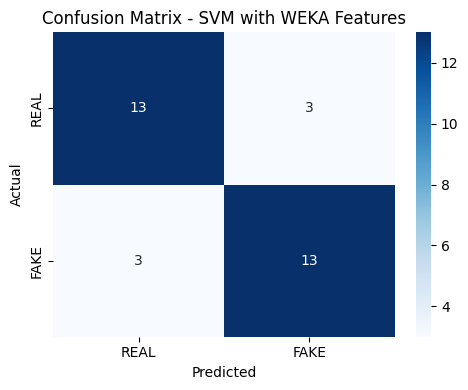

Confusion matrix for SVM with WEKA features saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/graphs/confusion_matrix_svm_weka.png


In [89]:
import seaborn as sns

cm_svm_weka = confusion_matrix(y_test, svm_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm_weka, annot=True, fmt='d', cmap='Blues', xticklabels=["REAL", "FAKE"], yticklabels=["REAL", "FAKE"])
plt.title('Confusion Matrix - SVM with WEKA Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()

cm_svm_weka_path = os.path.join(GRAPH_DIR, "confusion_matrix_svm_weka.png")
plt.savefig(cm_svm_weka_path)
plt.show()

print("Confusion matrix for SVM with WEKA features saved:", cm_svm_weka_path)

In [90]:
X_train_cnn = X_train_selected.reshape(X_train_selected.shape[0], X_train_selected.shape[1], 1)
X_test_cnn = X_test_selected.reshape(X_test_selected.shape[0], X_test_selected.shape[1], 1)

cnn_model = tf.keras.Sequential([
    layers.Input(shape=(X_train_cnn.shape[1], 1)),

    layers.Conv1D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    layers.Conv1D(128, kernel_size=3, activation="relu"),
    layers.GlobalMaxPooling1D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

cnn_probs = cnn_model.predict(X_test_cnn).ravel()
cnn_preds = (cnn_probs >= 0.5).astype(int)

cnn_model.save(os.path.join(MODEL_DIR, "final_cnn_model.keras"))

print("CNN Training Completed")
print(classification_report(y_test, cnn_preds, target_names=["REAL", "FAKE"]))

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.4020 - loss: 0.7058 - val_accuracy: 0.6154 - val_loss: 0.6925
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4804 - loss: 0.7009 - val_accuracy: 0.4615 - val_loss: 0.6917
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4902 - loss: 0.6914 - val_accuracy: 0.4615 - val_loss: 0.6930
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4804 - loss: 0.6913 - val_accuracy: 0.4615 - val_loss: 0.6926
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5000 - loss: 0.6937 - val_accuracy: 0.4615 - val_loss: 0.6949
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
CNN Training Completed
              precision    recall  f1-score   support

        REAL       0.00      0.00      0.00        16
        FAKE       0.50      1.00      0.67        16

    accuracy                           0.50        32
   macro avg       0.25      0.50      0.33        32
weighted avg       0.25      0.50      0.

In [91]:
print('Classification Report for CNN with WEKA features:')
print(classification_report(y_test, cnn_preds, target_names=["REAL", "FAKE"]))

Classification Report for CNN with WEKA features:
              precision    recall  f1-score   support

        REAL       0.00      0.00      0.00        16
        FAKE       0.50      1.00      0.67        16

    accuracy                           0.50        32
   macro avg       0.25      0.50      0.33        32
weighted avg       0.25      0.50      0.33        32



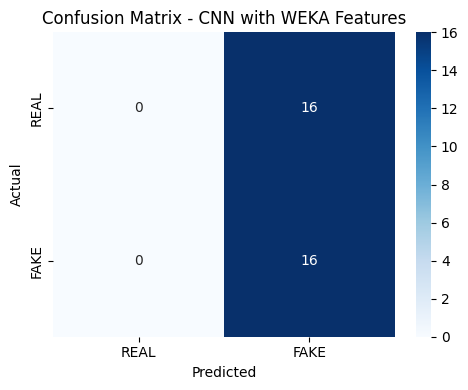

Confusion matrix for CNN with WEKA features saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/graphs/confusion_matrix_cnn_weka.png


In [92]:
import seaborn as sns

cm_cnn_weka = confusion_matrix(y_test, cnn_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_cnn_weka, annot=True, fmt='d', cmap='Blues', xticklabels=["REAL", "FAKE"], yticklabels=["REAL", "FAKE"])
plt.title('Confusion Matrix - CNN with WEKA Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()

cm_cnn_weka_path = os.path.join(GRAPH_DIR, "confusion_matrix_cnn_weka.png")
plt.savefig(cm_cnn_weka_path)
plt.show()

print("Confusion matrix for CNN with WEKA features saved:", cm_cnn_weka_path)

### LSTM Model Performance with WEKA Features

In [74]:
X_train_lstm = X_train_selected.reshape(X_train_selected.shape[0], X_train_selected.shape[1], 1)
X_test_lstm = X_test_selected.reshape(X_test_selected.shape[0], X_test_selected.shape[1], 1)

lstm_model = tf.keras.Sequential([
    layers.Input(shape=(X_train_lstm.shape[1], 1)),

    layers.LSTM(256, return_sequences=False),
    layers.Dropout(0.5),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    X_train_lstm,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

lstm_probs = lstm_model.predict(X_test_lstm).ravel()
lstm_preds = (lstm_probs >= 0.5).astype(int)

lstm_model.save(os.path.join(MODEL_DIR, "final_lstm_model.keras"))

print("LSTM Training Completed")
print(classification_report(y_test, lstm_preds, target_names=["REAL", "FAKE"]))

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 343ms/step - accuracy: 0.5686 - loss: 0.6919 - val_accuracy: 0.4615 - val_loss: 0.6942
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.5196 - loss: 0.6932 - val_accuracy: 0.4615 - val_loss: 0.6981
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - accuracy: 0.5098 - loss: 0.6923 - val_accuracy: 0.4615 - val_loss: 0.6956
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step - accuracy: 0.5000 - loss: 0.6868 - val_accuracy: 0.4615 - val_loss: 0.6952
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 309ms/step - accuracy: 0.5294 - loss: 0.6896 - val_accuracy: 0.4615 - val_loss: 0.6942
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
LSTM Training Completed
              precision    recall  f1-score   support

        REAL       0.00      0.00      0.00        16
        FAKE       0.50      1.00      0.67        16

    accuracy                           0.50        32
   macro avg       0.25      0.50      0.33        32
weighted avg       0.25      0.50  

In [75]:
print('Classification Report for LSTM with WEKA features:')
print(classification_report(y_test, lstm_preds, target_names=["REAL", "FAKE"]))

Classification Report for LSTM with WEKA features:
              precision    recall  f1-score   support

        REAL       0.00      0.00      0.00        16
        FAKE       0.50      1.00      0.67        16

    accuracy                           0.50        32
   macro avg       0.25      0.50      0.33        32
weighted avg       0.25      0.50      0.33        32



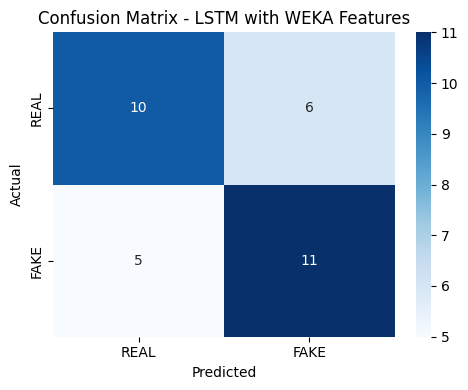

Confusion matrix for LSTM with WEKA features saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/graphs/confusion_matrix_lstm_weka.png


In [54]:
import seaborn as sns

cm_lstm_weka = confusion_matrix(y_test, lstm_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lstm_weka, annot=True, fmt='d', cmap='Blues', xticklabels=["REAL", "FAKE"], yticklabels=["REAL", "FAKE"])
plt.title('Confusion Matrix - LSTM with WEKA Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()

cm_lstm_weka_path = os.path.join(GRAPH_DIR, "confusion_matrix_lstm_weka.png")
plt.savefig(cm_lstm_weka_path)
plt.show()

print("Confusion matrix for LSTM with WEKA features saved:", cm_lstm_weka_path)

### Naive Bayes Model Performance with WEKA Features

In [77]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

# Initialize and train Gaussian Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train_selected, y_train)

# Make predictions and calculate probabilities
nb_probs = nb_model.predict_proba(X_test_selected)[:, 1]
nb_preds = (nb_probs >= 0.5).astype(int)

print('Naive Bayes Training Completed')
print('Classification Report for Naive Bayes with WEKA features:')
print(classification_report(y_test, nb_preds, target_names=["REAL", "FAKE"]))

Naive Bayes Training Completed
Classification Report for Naive Bayes with WEKA features:
              precision    recall  f1-score   support

        REAL       0.61      0.88      0.72        16
        FAKE       0.78      0.44      0.56        16

    accuracy                           0.66        32
   macro avg       0.69      0.66      0.64        32
weighted avg       0.69      0.66      0.64        32



In [78]:
nb_prediction_records = []

for i, row in test_df.reset_index(drop=True).iterrows():
    filename = row["filename"]
    true_label = row["label"]

    final_score = float(nb_probs[i]) # Using Naive Bayes probabilities
    predicted_label = classify_final_score(final_score)

    verdict = get_verdict(predicted_label, final_score)
    explanation = get_explanation(predicted_label, final_score)

    nb_prediction_records.append({
        "filename": filename,
        "true_label": true_label,
        "model": "Naive Bayes",
        "final_score": final_score,
        "predicted_label": predicted_label,
        "verdict": verdict,
        "explanation": explanation
    })

nb_prediction_df = pd.DataFrame(nb_prediction_records)

nb_prediction_path = os.path.join(PRED_DIR, "naive_bayes_predictions.csv")
nb_prediction_df.to_csv(nb_prediction_path, index=False)

print("Naive Bayes prediction file saved:", nb_prediction_path)
display(nb_prediction_df.head(20))

Naive Bayes prediction file saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/naive_bayes_predictions.csv


,filename,true_label,model,final_score,predicted_label,verdict,explanation
0,wclvkepakb.mp4,REAL,Naive Bayes,1.056604e-10,FAKE,The video is likely fake.,"The final fake probability score is 0.0000, wh..."
1,doniqevxeg.mp4,REAL,Naive Bayes,2.284674e-06,FAKE,The video is likely fake.,"The final fake probability score is 0.0000, wh..."
2,lbsltufgrh.mp4,FAKE,Naive Bayes,1.392311e-06,FAKE,The video is likely fake.,"The final fake probability score is 0.0000, wh..."
3,lbxbstcwwl.mp4,FAKE,Naive Bayes,3.659351e-01,FAKE,The video is likely fake.,"The final fake probability score is 0.3659, wh..."
4,bwsytelwkm.mp4,FAKE,Naive Bayes,9.999989e-01,REAL,The video is likely real.,"The final fake probability score is 1.0000, wh..."
5,jzupayeuln.mp4,REAL,Naive Bayes,1.085646e-01,FAKE,The video is likely fake.,"The final fake probability score is 0.1086, wh..."
6,prdrkaxeob.mp4,REAL,Naive Bayes,6.486951e-03,FAKE,The video is likely fake.,"The final fake probability score is 0.0065, wh..."
7,onbgbghesu.mp4,REAL,Naive Bayes,1.385671e-10,FAKE,The video is likely fake.,"The final fake probability score is 0.0000, wh..."
8,muhgixhdmd.mp4,FAKE,Naive Bayes,1.000000e+00,REAL,The video is likely real.,"The final fake probability score is 1.0000, wh..."
9,wmoigsbnem.mp4,FAKE,Naive Bayes,1.250147e-02,FAKE,The video is likely fake.,"The final fake probability score is 0.0125, wh..."


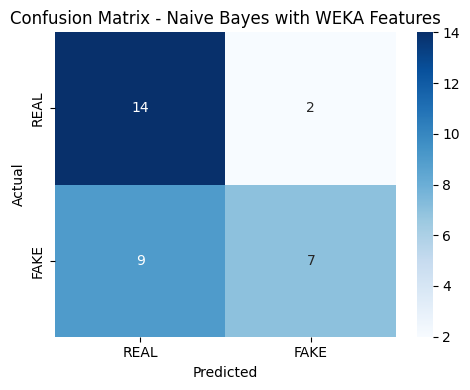

Confusion matrix for Naive Bayes with WEKA features saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/graphs/confusion_matrix_naive_bayes_weka.png


In [79]:
import seaborn as sns

cm_nb_weka = confusion_matrix(y_test, nb_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb_weka, annot=True, fmt='d', cmap='Blues', xticklabels=["REAL", "FAKE"], yticklabels=["REAL", "FAKE"])
plt.title('Confusion Matrix - Naive Bayes with WEKA Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()

cm_nb_weka_path = os.path.join(GRAPH_DIR, "confusion_matrix_naive_bayes_weka.png")
plt.savefig(cm_nb_weka_path)
plt.show()

print("Confusion matrix for Naive Bayes with WEKA features saved:", cm_nb_weka_path)

In [80]:
def get_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0)
    }

results = []

models_predictions = {
    "SVM": svm_preds,
    "CNN": cnn_preds,
    "LSTM": lstm_preds,
    "Naive Bayes": nb_preds
}

models_probs = {
    "SVM": svm_probs,
    "CNN": cnn_probs,
    "LSTM": lstm_probs,
    "Naive Bayes": nb_probs
}


for model_name, preds in models_predictions.items():
    metrics = get_metrics(y_test, preds)
    metrics["model"] = model_name
    results.append(metrics)

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df[["model", "accuracy", "precision", "recall", "f1_score"]]
comparison_df = comparison_df.sort_values(by="accuracy", ascending=False)

comparison_df.to_csv(os.path.join(REPORT_DIR, "model_comparison.csv"), index=False)

print(comparison_df)

best_model_name = comparison_df.iloc[0]["model"]
best_probs = models_probs[best_model_name]
best_preds = models_predictions[best_model_name]

print("Best Model:", best_model_name)

         model  accuracy  precision  recall  f1_score
0          SVM   0.81250   0.812500  0.8125  0.812500
3  Naive Bayes   0.65625   0.777778  0.4375  0.560000
1          CNN   0.62500   0.642857  0.5625  0.600000
2         LSTM   0.50000   0.500000  1.0000  0.666667
Best Model: SVM


In [81]:
# Save the Naive Bayes model if it's the best performing model
if best_model_name == "Naive Bayes":
    joblib.dump(nb_model, os.path.join(MODEL_DIR, "final_naive_bayes_model.pkl"))

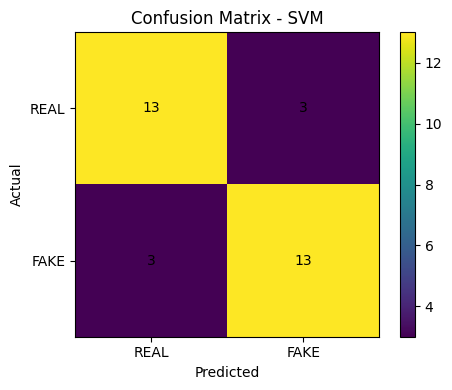

Confusion matrix saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/graphs/confusion_matrix_SVM.png


In [82]:
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["REAL", "FAKE"])
plt.yticks([0, 1], ["REAL", "FAKE"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()

cm_path = os.path.join(GRAPH_DIR, f"confusion_matrix_{best_model_name}.png")
plt.savefig(cm_path)
plt.show()

print("Confusion matrix saved:", cm_path)

In [93]:
prediction_records = []

for i, row in test_df.reset_index(drop=True).iterrows():
    filename = row["filename"]
    true_label = row["label"]

    final_score = float(best_probs[i])
    predicted_label = classify_final_score(final_score)

    verdict = get_verdict(predicted_label, final_score)
    explanation = get_explanation(predicted_label, final_score)

    prediction_records.append({
        "filename": filename,
        "true_label": true_label,
        "best_model": best_model_name,
        "final_score": final_score,
        "predicted_label": predicted_label,
        "verdict": verdict,
        "explanation": explanation
    })

prediction_df = pd.DataFrame(prediction_records)

prediction_path = os.path.join(PRED_DIR, "best_model_final_predictions.csv")
prediction_df.to_csv(prediction_path, index=False)

print("Final prediction file saved:", prediction_path)
display(prediction_df.head(20))

Final prediction file saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/best_model_final_predictions.csv


,filename,true_label,best_model,final_score,predicted_label,verdict,explanation
0,wclvkepakb.mp4,REAL,SVM,0.482769,FAKE,The video is likely fake.,"The final fake probability score is 0.4828, wh..."
1,doniqevxeg.mp4,REAL,SVM,0.485728,FAKE,The video is likely fake.,"The final fake probability score is 0.4857, wh..."
2,lbsltufgrh.mp4,FAKE,SVM,0.488597,FAKE,The video is likely fake.,"The final fake probability score is 0.4886, wh..."
3,lbxbstcwwl.mp4,FAKE,SVM,0.505767,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.5058, wh..."
4,bwsytelwkm.mp4,FAKE,SVM,0.510109,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.5101, wh..."
5,jzupayeuln.mp4,REAL,SVM,0.500000,FAKE,The video is likely fake.,"The final fake probability score is 0.5000, wh..."
6,prdrkaxeob.mp4,REAL,SVM,0.507673,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.5077, wh..."
7,onbgbghesu.mp4,REAL,SVM,0.480164,FAKE,The video is likely fake.,"The final fake probability score is 0.4802, wh..."
8,muhgixhdmd.mp4,FAKE,SVM,0.513184,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.5132, wh..."
9,wmoigsbnem.mp4,FAKE,SVM,0.508738,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.5087, wh..."


In [94]:
print(prediction_df["predicted_label"].value_counts())

uncertain_df = prediction_df[prediction_df["predicted_label"] == "UNCERTAIN"]
uncertain_path = os.path.join(UNCERTAIN_DIR, "uncertain_samples.csv")
uncertain_df.to_csv(uncertain_path, index=False)

print("Uncertain samples saved:", uncertain_path)

predicted_label
FAKE         17
UNCERTAIN    15
Name: count, dtype: int64
Uncertain samples saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/uncertain_samples/uncertain_samples.csv


In [95]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
from IPython.display import Image, display

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"

PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")
CSV_DIR = os.path.join(PROCESSED_DIR, "csv")
FRAMES_DIR = os.path.join(PROCESSED_DIR, "frames")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "data/outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
PRED_DIR = os.path.join(OUTPUT_DIR, "predictions")
EXPLAIN_DIR = os.path.join(OUTPUT_DIR, "explainability")

os.makedirs(EXPLAIN_DIR, exist_ok=True)

train_df = pd.read_csv(os.path.join(CSV_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(CSV_DIR, "test.csv"))

all_df = pd.concat([train_df, test_df]).reset_index(drop=True)

print("Train videos:", len(train_df))
print("Test videos:", len(test_df))
print("All videos:", len(all_df))

Train videos: 128
Test videos: 32
All videos: 160


In [96]:
frame_records = []

for _, row in all_df.iterrows():
    filename = row["filename"]
    video_id = Path(filename).stem
    target = int(row["target"])

    frame_folder = os.path.join(FRAMES_DIR, video_id)
    frame_paths = sorted(list(Path(frame_folder).glob("*.jpg")))

    for frame_path in frame_paths:
        frame_records.append({
            "frame_path": str(frame_path),
            "target": target,
            "video_filename": filename
        })

frame_df = pd.DataFrame(frame_records)

print("Total frames found:", len(frame_df))
print(frame_df["target"].value_counts())
frame_df.head()

Total frames found: 2400
target
0    1200
1    1200
Name: count, dtype: int64


,frame_path,target,video_filename
0,/content/drive/MyDrive/Deepfake_Project/data/p...,0,uhakqelqri.mp4
1,/content/drive/MyDrive/Deepfake_Project/data/p...,0,uhakqelqri.mp4
2,/content/drive/MyDrive/Deepfake_Project/data/p...,0,uhakqelqri.mp4
3,/content/drive/MyDrive/Deepfake_Project/data/p...,0,uhakqelqri.mp4
4,/content/drive/MyDrive/Deepfake_Project/data/p...,0,uhakqelqri.mp4


In [97]:
train_frame_df, val_frame_df = train_test_split(
    frame_df,
    test_size=0.2,
    random_state=42,
    stratify=frame_df["target"]
)

print("Train frames:", len(train_frame_df))
print("Validation frames:", len(val_frame_df))

Train frames: 1920
Validation frames: 480


In [98]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_frame_df,
    x_col="frame_path",
    y_col="target",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_frame_df,
    x_col="frame_path",
    y_col="target",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 1920 validated image filenames.
Found 480 validated image filenames.


In [99]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid", name="visual_output")(x)

visual_gradcam_model = Model(inputs, outputs)

visual_gradcam_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

visual_gradcam_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ visual_output (Dense)           │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [100]:
visual_model_path = os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

visual_history = visual_gradcam_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop],
    verbose=1
)

visual_gradcam_model.save(visual_model_path)

print("Visual Grad-CAM model saved:", visual_model_path)

Epoch 1/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.6297 - loss: 0.6753 - val_accuracy: 0.7250 - val_loss: 0.6105
Epoch 2/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6490 - loss: 0.6535 - val_accuracy: 0.6479 - val_loss: 0.6226
Epoch 3/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.6573 - loss: 0.6461 - val_accuracy: 0.6812 - val_loss: 0.6101
Epoch 4/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.6385 - loss: 0.6520 - val_accuracy: 0.7042 - val_loss: 0.6118
Epoch 5/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.6521 - loss: 0.6325 - val_accuracy: 0.7063 - val_loss: 0.6067
Visual Grad-CAM model saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/models/visual_mobilenetv2_gradcam_model.keras


In [101]:
visual_model_path = os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras")

visual_gradcam_model = tf.keras.models.load_model(visual_model_path)

print("Visual model loaded successfully.")

Visual model loaded successfully.


In [102]:
def get_mobilenet_base_model(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and "mobilenet" in layer.name.lower():
            return layer
    raise ValueError("MobileNetV2 base model not found inside visual model.")


def make_gradcam_heatmap(img_array, full_model):
    base_model = get_mobilenet_base_model(full_model)

    # MobileNetV2 final convolutional feature map
    last_conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=base_model.output
    )

    base_index = full_model.layers.index(base_model)

    classifier_input = tf.keras.Input(shape=base_model.output.shape[1:])
    x = classifier_input

    for layer in full_model.layers[base_index + 1:]:
        x = layer(x)

    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = last_conv_model(img_array)
        tape.watch(conv_outputs)

        predictions = classifier_model(conv_outputs)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value == 0:
        return heatmap.numpy()

    heatmap = heatmap / max_value

    return heatmap.numpy()


def save_gradcam_image(frame_path, output_path, model):
    img = image.load_img(frame_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    heatmap = make_gradcam_heatmap(img_array, model)

    original_img = cv2.imread(frame_path)
    original_img = cv2.resize(original_img, (224, 224))

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    gradcam_img = cv2.addWeighted(original_img, 0.6, heatmap_color, 0.4, 0)

    cv2.imwrite(output_path, gradcam_img)

    return output_path

Grad-CAM saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/wclvkepakb_gradcam_test.jpg


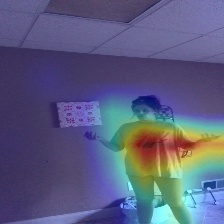

In [103]:
sample_row = test_df.iloc[0]

filename = sample_row["filename"]
video_id = Path(filename).stem

frame_folder = os.path.join(FRAMES_DIR, video_id)
frame_paths = sorted(list(Path(frame_folder).glob("*.jpg")))

selected_frame = str(frame_paths[len(frame_paths) // 2])

output_path = os.path.join(EXPLAIN_DIR, f"{video_id}_gradcam_test.jpg")

save_gradcam_image(
    frame_path=selected_frame,
    output_path=output_path,
    model=visual_gradcam_model
)

print("Grad-CAM saved:", output_path)
display(Image(filename=output_path))

In [104]:
prediction_path = os.path.join(PRED_DIR, "best_model_final_predictions.csv")

prediction_df = pd.read_csv(prediction_path)

print("Loaded predictions:", len(prediction_df))
prediction_df.head()

Loaded predictions: 32


,filename,true_label,best_model,final_score,predicted_label,verdict,explanation
0,wclvkepakb.mp4,REAL,SVM,0.482769,FAKE,The video is likely fake.,"The final fake probability score is 0.4828, wh..."
1,doniqevxeg.mp4,REAL,SVM,0.485728,FAKE,The video is likely fake.,"The final fake probability score is 0.4857, wh..."
2,lbsltufgrh.mp4,FAKE,SVM,0.488597,FAKE,The video is likely fake.,"The final fake probability score is 0.4886, wh..."
3,lbxbstcwwl.mp4,FAKE,SVM,0.505767,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.5058, wh..."
4,bwsytelwkm.mp4,FAKE,SVM,0.510109,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.5101, wh..."


In [114]:
gradcam_paths = []

for _, row in tqdm(prediction_df.iterrows(), total=len(prediction_df)):
    filename = row["filename"]
    video_id = Path(filename).stem

    frame_folder = os.path.join(FRAMES_DIR, video_id)
    frame_paths = sorted(list(Path(frame_folder).glob("*.jpg")))

    if len(frame_paths) == 0:
        gradcam_paths.append("")
        continue

    # Use middle frame for explanation
    selected_frame = str(frame_paths[len(frame_paths) // 2])

    output_path = os.path.join(
        EXPLAIN_DIR,
        f"{video_id}_lstm_visual_gradcam.jpg"
    )

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=output_path,
            model=visual_gradcam_model
        )

        gradcam_paths.append(output_path)

    except Exception as e:
        print("Grad-CAM failed for:", filename)
        print("Error:", e)
        gradcam_paths.append("")

prediction_df["gradcam_image_path"] = gradcam_paths

final_gradcam_path = os.path.join(
    PRED_DIR,
    "final_predictions_with_gradcam.csv"
)

prediction_df.to_csv(final_lstm_gradcam_path, index=False)

print("Final prediction file with Grad-CAM saved:")
print(final_gradcam_path)

prediction_df.head()

100%|██████████| 32/32 [00:36<00:00,  1.15s/it]

Final prediction file with Grad-CAM saved:
/content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/final_predictions_with_gradcam.csv


,filename,true_label,best_model,final_score,predicted_label,verdict,explanation,gradcam_image_path
0,wclvkepakb.mp4,REAL,SVM,0.482769,FAKE,The video is likely fake.,"The final fake probability score is 0.4828, wh...",/content/drive/MyDrive/Deepfake_Project/data/o...
1,doniqevxeg.mp4,REAL,SVM,0.485728,FAKE,The video is likely fake.,"The final fake probability score is 0.4857, wh...",/content/drive/MyDrive/Deepfake_Project/data/o...
2,lbsltufgrh.mp4,FAKE,SVM,0.488597,FAKE,The video is likely fake.,"The final fake probability score is 0.4886, wh...",/content/drive/MyDrive/Deepfake_Project/data/o...
3,lbxbstcwwl.mp4,FAKE,SVM,0.505767,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.5058, wh...",/content/drive/MyDrive/Deepfake_Project/data/o...
4,bwsytelwkm.mp4,FAKE,SVM,0.510109,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.5101, wh...",/content/drive/MyDrive/Deepfake_Project/data/o...


Filename: lbsltufgrh.mp4
True Label: FAKE
Predicted Label: FAKE
Final Score: 0.4885969174760842
Grad-CAM: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/lbsltufgrh_lstm_visual_gradcam.jpg


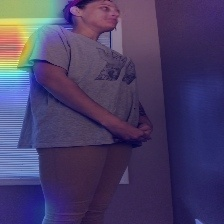

--------------------------------------------------------------------------------
Filename: iocjgjemeb.mp4
True Label: FAKE
Predicted Label: FAKE
Final Score: 0.4848657172784817
Grad-CAM: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/iocjgjemeb_lstm_visual_gradcam.jpg


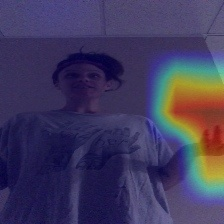

--------------------------------------------------------------------------------
Filename: bkcztuqxbp.mp4
True Label: FAKE
Predicted Label: FAKE
Final Score: 0.5
Grad-CAM: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/bkcztuqxbp_lstm_visual_gradcam.jpg


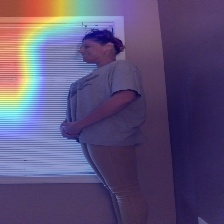

--------------------------------------------------------------------------------
Filename: vinguynpez.mp4
True Label: FAKE
Predicted Label: FAKE
Final Score: 0.4872281913615922
Grad-CAM: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/vinguynpez_lstm_visual_gradcam.jpg


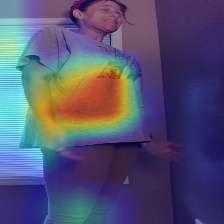

--------------------------------------------------------------------------------
Filename: achdeirhym.mp4
True Label: FAKE
Predicted Label: FAKE
Final Score: 0.5
Grad-CAM: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/achdeirhym_lstm_visual_gradcam.jpg


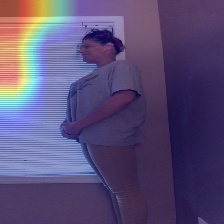

--------------------------------------------------------------------------------


In [112]:
matching_predictions = prediction_df[prediction_df["true_label"] == prediction_df["predicted_label"]]

sample_gradcams = matching_predictions[matching_predictions["gradcam_image_path"] != ""].head(5)

if sample_gradcams.empty:
    print("No videos found where true label matches predicted label.")
else:
    for _, row in sample_gradcams.iterrows():
        print("Filename:", row["filename"])
        print("True Label:", row["true_label"])
        print("Predicted Label:", row["predicted_label"])
        print("Final Score:", row["final_score"])
        print("Grad-CAM:", row["gradcam_image_path"])
        display(Image(filename=row["gradcam_image_path"]))
        print("-" * 80)

### Test a video from the test set with the best performing model (SVM)

Selected random test video: exseruhiuk.mp4 (True Label: REAL)

--- Feature Extraction ---
Extracting frames for exseruhiuk.mp4...
Frames extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/frames/exseruhiuk
Extracting audio for exseruhiuk.mp4...
Audio extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/exseruhiuk.wav
Extracting visual features for exseruhiuk.mp4...
Extracting audio features for exseruhiuk.mp4...
Transcribing audio for exseruhiuk.mp4...
Transcript:  addictive. First of all, studies show that they have the same type of chemicals that is junk food through the

--- Feature Preprocessing ---
Combined raw features shape for test video (with interaction features): (1, 2022)
Scaled and selected (WEKA-like) features shape for test video: (1, 50)

--- Prediction & Explanation ---
Prediction score for exseruhiuk.mp4: 0.4106
Predicted Label: FAKE
Verdict: The video is likely fake.
Explanation: The final fake probability score is 0.4106, whic

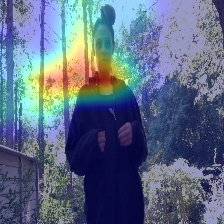

In [111]:
random_test_video_row = test_df.sample(1).iloc[0]

TEST_VIDEO_FILENAME = random_test_video_row["filename"]
TEST_VIDEO_PATH = random_test_video_row["video_path"]
TRUE_LABEL = random_test_video_row["label"]

print(f"Selected random test video: {TEST_VIDEO_FILENAME} (True Label: {TRUE_LABEL})")

# Create a dummy DataFrame for the new video to reuse existing processing logic
new_video_df_test = pd.DataFrame({
    "filename": [TEST_VIDEO_FILENAME],
    "video_path": [TEST_VIDEO_PATH],
    "label": ["UNKNOWN"], # Placeholder
    "target": [-1], # Placeholder
    "original": [None]
})

print("\n--- Feature Extraction ---")

# 1. Extract Frames for the Test Video
new_video_id_test = Path(TEST_VIDEO_FILENAME).stem
new_frames_output_folder_test = os.path.join(FRAMES_DIR, new_video_id_test)

print(f"Extracting frames for {TEST_VIDEO_FILENAME}...")
frame_extracted_test = extract_frames(TEST_VIDEO_PATH, new_frames_output_folder_test, NUM_FRAMES)

if frame_extracted_test:
    print(f"Frames extracted to: {new_frames_output_folder_test}")
else:
    print(f"Failed to extract frames for {TEST_VIDEO_FILENAME}")

# 2. Extract Audio for the Test Video
new_audio_path_test = os.path.join(AUDIO_DIR, f"{new_video_id_test}.wav")

print(f"Extracting audio for {TEST_VIDEO_FILENAME}...")
audio_extracted_test = extract_audio(TEST_VIDEO_PATH, new_audio_path_test)

if audio_extracted_test:
    print(f"Audio extracted to: {new_audio_path_test}")
else:
    print(f"Failed to extract audio for {TEST_VIDEO_FILENAME}")

# 3. Extract Visual Features for the Test Video
print(f"Extracting visual features for {TEST_VIDEO_FILENAME}...")
new_visual_feature_test = extract_visual_feature(new_video_id_test)

new_visual_records_test = [{
    "filename": TEST_VIDEO_FILENAME
}]
for i, value in enumerate(new_visual_feature_test):
    new_visual_records_test[0][f"v_{i}"] = value

new_visual_df_test = pd.DataFrame(new_visual_records_test)

# 4. Extract Audio Features for the Test Video
print(f"Extracting audio features for {TEST_VIDEO_FILENAME}...")
new_audio_feature_test = extract_audio_feature(new_video_id_test)

new_audio_records_test = [{
    "filename": TEST_VIDEO_FILENAME
}]
for i, value in enumerate(new_audio_feature_test):
    new_audio_records_test[0][f"a_{i}"] = value

new_audio_df_test = pd.DataFrame(new_audio_records_test)

# 5. Transcribe Audio and Extract Text Features for the Test Video
print(f"Transcribing audio for {TEST_VIDEO_FILENAME}...")
new_transcript_test = transcribe_audio(new_video_id_test)

new_text_df_test = pd.DataFrame({
    "filename": [TEST_VIDEO_FILENAME],
    "transcript": [new_transcript_test]
}).set_index("filename")

print("Transcript:", new_transcript_test)

print("\n--- Feature Preprocessing ---")

# 6. Combine All Features for the Test Video
new_X_visual_test = new_visual_df_test[visual_cols].values
new_X_audio_test = new_audio_df_test[audio_cols].values
new_X_text_test = tfidf.transform([new_text_df_test.loc[TEST_VIDEO_FILENAME, "transcript"]]).toarray()

new_X_combined_base_test = np.hstack([new_X_visual_test, new_X_audio_test, new_X_text_test])

# Calculate interaction features for the new video
v0_idx_in_base_test = visual_cols.index('v_0') if 'v_0' in visual_cols else -1
a0_idx_in_base_test = len(visual_cols) + audio_cols.index('a_0') if 'a_0' in audio_cols else -1
text_the_idx_in_base_test = len(visual_cols) + len(audio_cols) + (tfidf.vocabulary_['the'] if 'the' in tfidf.vocabulary_ else -1)

new_interaction_features_test = []

if v0_idx_in_base_test != -1 and a0_idx_in_base_test != -1:
    interaction_v0_a0_new_test = new_X_combined_base_test[:, v0_idx_in_base_test] * new_X_combined_base_test[:, a0_idx_in_base_test]
    new_interaction_features_test.append(interaction_v0_a0_new_test.reshape(-1, 1))

if v0_idx_in_base_test != -1 and text_the_idx_in_base_test != -1 and 'the' in tfidf.vocabulary_:
    interaction_v0_text_the_new_test = new_X_combined_base_test[:, v0_idx_in_base_test] * new_X_combined_base_test[:, text_the_idx_in_base_test]
    new_interaction_features_test.append(interaction_v0_text_the_new_test.reshape(-1, 1))

if new_interaction_features_test:
    new_X_combined_test = np.hstack([new_X_combined_base_test] + new_interaction_features_test)
else:
    new_X_combined_test = new_X_combined_base_test

print("Combined raw features shape for test video (with interaction features):", new_X_combined_test.shape)

# 7. Scale and Select Features for the Test Video using TRAINED scaler and selector
scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
selector = joblib.load(os.path.join(MODEL_DIR, "feature_selector.pkl"))

new_X_scaled_test = scaler.transform(new_X_combined_test)
new_X_selected_test = selector.transform(new_X_scaled_test)

print("Scaled and selected (WEKA-like) features shape for test video:", new_X_selected_test.shape)

print("\n--- Prediction & Explanation ---")

# 8. Load Best Model (SVM) and Predict for the Test Video
svm_model = joblib.load(os.path.join(MODEL_DIR, "svm_model.pkl"))

new_final_score_test = svm_model.predict_proba(new_X_selected_test)[:, 1]
new_final_score_test = float(new_final_score_test[0])

print(f"Prediction score for {TEST_VIDEO_FILENAME}: {new_final_score_test:.4f}")

# 9. Interpret Prediction
new_predicted_label_test = classify_final_score(new_final_score_test)
new_verdict_test = get_verdict(new_predicted_label_test, new_final_score_test)
new_explanation_test = get_explanation(new_predicted_label_test, new_final_score_test)

print("Predicted Label:", new_predicted_label_test)
print("Verdict:", new_verdict_test)
print("Explanation:", new_explanation_test)
print("True Label:", TRUE_LABEL)

# 10. Generate Grad-CAM for the Test Video
new_frame_paths_test = sorted(list(Path(new_frames_output_folder_test).glob("*.jpg")))

if new_frame_paths_test:
    selected_frame_test = str(new_frame_paths_test[len(new_frame_paths_test) // 2])
    new_gradcam_output_path_test = os.path.join(EXPLAIN_DIR, f"{new_video_id_test}_gradcam_test_video.jpg")

    visual_gradcam_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras"))

    try:
        save_gradcam_image(
            frame_path=selected_frame_test,
            output_path=new_gradcam_output_path_test,
            model=visual_gradcam_model
        )
        print("Grad-CAM image generated:", new_gradcam_output_path_test)
        display(Image(filename=new_gradcam_output_path_test))
    except Exception as e:
        print(f"Failed to generate Grad-CAM for {TEST_VIDEO_FILENAME}: {e}")
else:
    print("No frames found to generate Grad-CAM.")

Selected random video: qyqufaskjs.mp4 (True Label: REAL)
New video path set: /content/drive/MyDrive/Deepfake_Project/data/raw/dfdc_train_part_00/qyqufaskjs.mp4


,filename,video_path,label,target,original
0,qyqufaskjs.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,UNKNOWN,-1,None


Extracting frames for qyqufaskjs.mp4...
Frames extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/frames/qyqufaskjs
Extracting audio for qyqufaskjs.mp4...
Audio extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/qyqufaskjs.wav
Extracting visual features for qyqufaskjs.mp4...


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,qyqufaskjs.mp4,0.0,0.000294,0.432521,0.150413,0.218223,0.945643,0.129838,0.011073,0.320316,...,0.296404,0.552961,0.173334,0.020752,0.014382,0.127902,0.592089,1.812181,0.756257,0.115472


Extracting audio features for qyqufaskjs.mp4...


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,qyqufaskjs.mp4,-466.448547,93.671402,20.0758,27.386126,-5.711513,-5.955157,-20.271883,-8.408575,-16.389904,...,0.642629,0.47935,0.518739,0.62211,0.677712,0.628149,0.480156,0.554573,0.52267,0.510666


Transcribing audio for qyqufaskjs.mp4...
Transcript:  There's nobody's in a field guilty for killing zombies. It's their time to go if it's the apocalypse. And you gotta do what you gotta do to protect yourself.


,transcript
filename,
qyqufaskjs.mp4,There's nobody's in a field guilty for killin...


WEKA selected features shape for new video: (1, 50)
Prediction score for qyqufaskjs.mp4: 0.5108
Predicted Label: UNCERTAIN
Verdict: The model is not confident. Manual review is recommended.
Explanation: The final fake probability score is 0.5108, which lies between real and fake thresholds.
Grad-CAM image generated: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/qyqufaskjs_gradcam_new_video.jpg


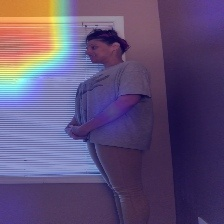

In [107]:
random_video_row = all_df.sample(1).iloc[0]

NEW_VIDEO_FILENAME = random_video_row["filename"]
NEW_VIDEO_PATH = random_video_row["video_path"]
TRUE_LABEL = random_video_row["label"]

print(f"Selected random video: {NEW_VIDEO_FILENAME} (True Label: {TRUE_LABEL})")
print("New video path set:", NEW_VIDEO_PATH)

# Create a dummy DataFrame for the new video to reuse existing processing logic
new_video_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "video_path": [NEW_VIDEO_PATH],
    "label": ["UNKNOWN"], # Placeholder
    "target": [-1], # Placeholder
    "original": [None]
})

display(new_video_df.head())

# 1. Extract Frames for the New Video
new_video_id = Path(NEW_VIDEO_FILENAME).stem
new_frames_output_folder = os.path.join(FRAMES_DIR, new_video_id)

print(f"Extracting frames for {NEW_VIDEO_FILENAME}...")
frame_extracted = extract_frames(NEW_VIDEO_PATH, new_frames_output_folder, NUM_FRAMES)

if frame_extracted:
    print(f"Frames extracted to: {new_frames_output_folder}")
else:
    print(f"Failed to extract frames for {NEW_VIDEO_FILENAME}")

# 2. Extract Audio for the New Video
new_audio_path = os.path.join(AUDIO_DIR, f"{new_video_id}.wav")

print(f"Extracting audio for {NEW_VIDEO_FILENAME}...")
audio_extracted = extract_audio(NEW_VIDEO_PATH, new_audio_path)

if audio_extracted:
    print(f"Audio extracted to: {new_audio_path}")
else:
    print(f"Failed to extract audio for {NEW_VIDEO_FILENAME}")

# 3. Extract Visual Features for the New Video
print(f"Extracting visual features for {NEW_VIDEO_FILENAME}...")
new_visual_feature = extract_visual_feature(new_video_id)

new_visual_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_visual_feature):
    new_visual_records[0][f"v_{i}"] = value

new_visual_df = pd.DataFrame(new_visual_records)
display(new_visual_df.head())

# 4. Extract Audio Features for the New Video
print(f"Extracting audio features for {NEW_VIDEO_FILENAME}...")
new_audio_feature = extract_audio_feature(new_video_id)

new_audio_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_audio_feature):
    new_audio_records[0][f"a_{i}"] = value

new_audio_df = pd.DataFrame(new_audio_records)
display(new_audio_df.head())

# 5. Transcribe Audio and Extract Text Features for the New Video
print(f"Transcribing audio for {NEW_VIDEO_FILENAME}...")
new_transcript = transcribe_audio(new_video_id)

new_text_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "transcript": [new_transcript]
}).set_index("filename")

print("Transcript:", new_transcript)
display(new_text_df.head())

# 6. Combine All Features for the New Video (for potential interaction features)
new_X_visual = new_visual_df[visual_cols].values
new_X_audio = new_audio_df[audio_cols].values
new_X_text = tfidf.transform([new_text_df.loc[NEW_VIDEO_FILENAME, "transcript"]]).toarray()

new_X_combined = np.hstack([new_X_visual, new_X_audio, new_X_text])

# 7. Prepare WEKA Features for the New Video
# Load the full WEKA features DataFrame
weka_df = pd.read_csv(WEKA_CSV_PATH)

# Filter for the current new video filename
new_weka_features_row = weka_df[weka_df['filename'] == NEW_VIDEO_FILENAME]

if new_weka_features_row.empty:
    raise ValueError(f"WEKA features not found for {NEW_VIDEO_FILENAME}. Please ensure the video was part of the original dataset used to generate WEKA features.")

# Extract only the feature columns (excluding 'filename' and 'target')
new_X_selected = new_weka_features_row[WEKA_FEATURE_COLUMNS].values

print("WEKA selected features shape for new video:", new_X_selected.shape)

# 8. Load Best Model (SVM) and Predict for the New Video
# Load the best model (SVM)
svm_model = joblib.load(os.path.join(MODEL_DIR, "svm_model.pkl")) # Assuming SVM is saved as .pkl

# SVM prediction
new_final_score = svm_model.predict_proba(new_X_selected)[:, 1]
new_final_score = float(new_final_score[0])

print(f"Prediction score for {NEW_VIDEO_FILENAME}: {new_final_score:.4f}")

# 9. Interpret Prediction
new_predicted_label = classify_final_score(new_final_score)
new_verdict = get_verdict(new_predicted_label, new_final_score)
new_explanation = get_explanation(new_predicted_label, new_final_score)

print("Predicted Label:", new_predicted_label)
print("Verdict:", new_verdict)
print("Explanation:", new_explanation)

# 10. Generate Grad-CAM for the New Video
new_frame_paths = sorted(list(Path(new_frames_output_folder).glob("*.jpg")))

if new_frame_paths:
    selected_frame = str(new_frame_paths[len(new_frame_paths) // 2])
    new_gradcam_output_path = os.path.join(EXPLAIN_DIR, f"{new_video_id}_gradcam_new_video.jpg")

    # Load the visual Grad-CAM model
    visual_gradcam_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras"))

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=new_gradcam_output_path,
            model=visual_gradcam_model
        )
        print("Grad-CAM image generated:", new_gradcam_output_path)
        display(Image(filename=new_gradcam_output_path))
    except Exception as e:
        print(f"Failed to generate Grad-CAM for {NEW_VIDEO_FILENAME}: {e}")
else:
    print("No frames found to generate Grad-CAM.")

New video path set: /content/drive/MyDrive/my1.mp4


,filename,video_path,label,target,original
0,my1.mp4,/content/drive/MyDrive/my1.mp4,UNKNOWN,-1,None


Extracting frames for my1.mp4...
Frames extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/frames/my1
Extracting audio for my1.mp4...
Audio extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/my1.wav
Extracting visual features for my1.mp4...


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,my1.mp4,0.045448,0.897333,0.211385,0.25758,0.230682,0.257641,0.082635,0.381627,0.063113,...,0.063697,0.528531,0.751797,1.085291,0.397981,1.141974,0.375926,0.42174,0.454807,0.213901


Extracting audio features for my1.mp4...


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,my1.mp4,-382.707764,130.854797,-18.479506,27.687174,-0.563039,1.198451,-11.071355,-7.697257,-9.34627,...,0.843645,0.75677,0.716468,0.687034,0.756703,0.668324,0.610633,0.627199,0.591461,0.526318


Transcribing audio for my1.mp4...
Transcript: おرßenึwardב


,transcript
filename,
my1.mp4,おرßenึwardב


Combined raw features shape for new video (with interaction features): (1, 2022)
Scaled and selected (WEKA-like) features shape for new video: (1, 50)
Prediction score for my1.mp4: 0.5056
Predicted Label: UNCERTAIN
Verdict: The model is not confident. Manual review is recommended.
Explanation: The final fake probability score is 0.5056, which lies between real and fake thresholds.
Grad-CAM image generated: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/my1_gradcam_new_video.jpg


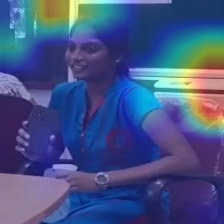

In [ ]:
NEW_VIDEO_FILENAME = "my1.mp4" # Adjust if your filename is different
NEW_VIDEO_PATH = os.path.join("/content/drive/MyDrive/", NEW_VIDEO_FILENAME)

print("New video path set:", NEW_VIDEO_PATH)

# Create a dummy DataFrame for the new video to reuse existing processing logic
new_video_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "video_path": [NEW_VIDEO_PATH],
    "label": ["UNKNOWN"], # Placeholder
    "target": [-1], # Placeholder
    "original": [None]
})

display(new_video_df.head())

# 1. Extract Frames for the New Video
new_video_id = Path(NEW_VIDEO_FILENAME).stem
new_frames_output_folder = os.path.join(FRAMES_DIR, new_video_id)

print(f"Extracting frames for {NEW_VIDEO_FILENAME}...")
frame_extracted = extract_frames(NEW_VIDEO_PATH, new_frames_output_folder, NUM_FRAMES)

if frame_extracted:
    print(f"Frames extracted to: {new_frames_output_folder}")
else:
    print(f"Failed to extract frames for {NEW_VIDEO_FILENAME}")

# 2. Extract Audio for the New Video
new_audio_path = os.path.join(AUDIO_DIR, f"{new_video_id}.wav")

print(f"Extracting audio for {NEW_VIDEO_FILENAME}...")
audio_extracted = extract_audio(NEW_VIDEO_PATH, new_audio_path)

if audio_extracted:
    print(f"Audio extracted to: {new_audio_path}")
else:
    print(f"Failed to extract audio for {NEW_VIDEO_FILENAME}")

# 3. Extract Visual Features for the New Video
print(f"Extracting visual features for {NEW_VIDEO_FILENAME}...")
new_visual_feature = extract_visual_feature(new_video_id)

new_visual_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_visual_feature):
    new_visual_records[0][f"v_{i}"] = value

new_visual_df = pd.DataFrame(new_visual_records)
display(new_visual_df.head())

# 4. Extract Audio Features for the New Video
print(f"Extracting audio features for {NEW_VIDEO_FILENAME}...")
new_audio_feature = extract_audio_feature(new_video_id)

new_audio_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_audio_feature):
    new_audio_records[0][f"a_{i}"] = value

new_audio_df = pd.DataFrame(new_audio_records)
display(new_audio_df.head())

# 5. Transcribe Audio and Extract Text Features for the New Video
print(f"Transcribing audio for {NEW_VIDEO_FILENAME}...")
new_transcript = transcribe_audio(new_video_id)

new_text_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "transcript": [new_transcript]
}).set_index("filename")

print("Transcript:", new_transcript)
display(new_text_df.head())

# 6. Combine All Features for the New Video
# These raw features are now used as input to the trained scaler and selector
new_X_visual = new_visual_df[visual_cols].values
new_X_audio = new_audio_df[audio_cols].values
new_X_text = tfidf.transform([new_text_df.loc[NEW_VIDEO_FILENAME, "transcript"]]).toarray()

# Combine base features
new_X_combined_base = np.hstack([new_X_visual, new_X_audio, new_X_text])

# Calculate interaction features for the new video
# Re-use logic from training for consistency
# Determine indices for 'v_0', 'a_0', and 'text_the' within new_X_combined_base
v0_idx_in_base = visual_cols.index('v_0') if 'v_0' in visual_cols else -1
a0_idx_in_base = len(visual_cols) + audio_cols.index('a_0') if 'a_0' in audio_cols else -1
text_the_idx_in_base = len(visual_cols) + len(audio_cols) + (tfidf.vocabulary_['the'] if 'the' in tfidf.vocabulary_ else -1)

new_interaction_features = []

if v0_idx_in_base != -1 and a0_idx_in_base != -1:
    interaction_v0_a0_new = new_X_combined_base[:, v0_idx_in_base] * new_X_combined_base[:, a0_idx_in_base]
    new_interaction_features.append(interaction_v0_a0_new.reshape(-1, 1))

if v0_idx_in_base != -1 and text_the_idx_in_base != -1 and 'the' in tfidf.vocabulary_:
    interaction_v0_text_the_new = new_X_combined_base[:, v0_idx_in_base] * new_X_combined_base[:, text_the_idx_in_base]
    new_interaction_features.append(interaction_v0_text_the_new.reshape(-1, 1))

if new_interaction_features:
    new_X_combined = np.hstack([new_X_combined_base] + new_interaction_features)
else:
    new_X_combined = new_X_combined_base

print("Combined raw features shape for new video (with interaction features):", new_X_combined.shape)

# 7. Scale and Select Features for the New Video using TRAINED scaler and selector
# This step ensures the new video's features are transformed into the 50 WEKA features format
# that the SVM model was trained on.
scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
selector = joblib.load(os.path.join(MODEL_DIR, "feature_selector.pkl"))

new_X_scaled = scaler.transform(new_X_combined)
new_X_selected = selector.transform(new_X_scaled)

print("Scaled and selected (WEKA-like) features shape for new video:", new_X_selected.shape)

# 8. Load Best Model (SVM) and Predict for the New Video
# Load the best model (SVM)
svm_model = joblib.load(os.path.join(MODEL_DIR, "svm_model.pkl")) # Assuming SVM is saved as .pkl

# SVM prediction: directly use the new_X_selected (WEKA features)
new_final_score = svm_model.predict_proba(new_X_selected)[:, 1]
new_final_score = float(new_final_score[0])

print(f"Prediction score for {NEW_VIDEO_FILENAME}: {new_final_score:.4f}")

# 9. Interpret Prediction
new_predicted_label = classify_final_score(new_final_score)
new_verdict = get_verdict(new_predicted_label, new_final_score)
new_explanation = get_explanation(new_predicted_label, new_final_score)

print("Predicted Label:", new_predicted_label)
print("Verdict:", new_verdict)
print("Explanation:", new_explanation)

# 10. Generate Grad-CAM for the New Video
new_frame_paths = sorted(list(Path(new_frames_output_folder).glob("*.jpg")))

if new_frame_paths:
    selected_frame = str(new_frame_paths[len(new_frame_paths) // 2])
    new_gradcam_output_path = os.path.join(EXPLAIN_DIR, f"{new_video_id}_gradcam_new_video.jpg")

    # Load the visual Grad-CAM model
    visual_gradcam_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras"))

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=new_gradcam_output_path,
            model=visual_gradcam_model
        )
        print("Grad-CAM image generated:", new_gradcam_output_path)
        display(Image(filename=new_gradcam_output_path))
    except Exception as e:
        print(f"Failed to generate Grad-CAM for {NEW_VIDEO_FILENAME}: {e}")
else:
    print("No frames found to generate Grad-CAM.")

New video path set: /content/drive/MyDrive/my2.mp4


,filename,video_path,label,target,original
0,my2.mp4,/content/drive/MyDrive/my2.mp4,UNKNOWN,-1,None


Extracting frames for my2.mp4...
Frames extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/frames/my2
Extracting audio for my2.mp4...
Audio extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/my2.wav
Extracting visual features for my2.mp4...


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,my2.mp4,0.059864,1.018467,0.142153,0.417605,0.009119,0.335589,0.052633,1.262263,0.19067,...,0.964407,1.342368,2.502553,0.008257,0.000403,0.919594,0.002039,0.017403,1.459862,0.044094


Extracting audio features for my2.mp4...


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,my2.mp4,-290.79071,115.540184,-7.419962,22.281208,-4.033728,4.035691,-11.912091,-6.527907,-12.423347,...,0.498168,0.488868,0.531286,0.584478,0.546848,0.688722,0.534834,0.519543,0.558753,0.579356


Transcribing audio for my2.mp4...
Transcript: 


,transcript
filename,
my2.mp4,


Combined raw features shape for new video (with interaction features): (1, 2022)
Scaled and selected (WEKA-like) features shape for new video: (1, 50)
Prediction score for my2.mp4: 0.4702
Predicted Label: UNCERTAIN
Verdict: The model is not confident. Manual review is recommended.
Explanation: The final fake probability score is 0.4702, which lies between real and fake thresholds.
Grad-CAM image generated: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/my2_gradcam_new_video.jpg


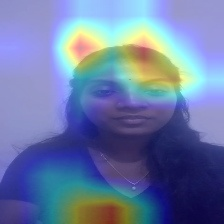

In [ ]:
NEW_VIDEO_FILENAME = "my2.mp4" # Adjust if your filename is different
NEW_VIDEO_PATH = os.path.join("/content/drive/MyDrive/", NEW_VIDEO_FILENAME)

print("New video path set:", NEW_VIDEO_PATH)

# Create a dummy DataFrame for the new video to reuse existing processing logic
new_video_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "video_path": [NEW_VIDEO_PATH],
    "label": ["UNKNOWN"], # Placeholder
    "target": [-1], # Placeholder
    "original": [None]
})

display(new_video_df.head())

# 1. Extract Frames for the New Video
new_video_id = Path(NEW_VIDEO_FILENAME).stem
new_frames_output_folder = os.path.join(FRAMES_DIR, new_video_id)

print(f"Extracting frames for {NEW_VIDEO_FILENAME}...")
frame_extracted = extract_frames(NEW_VIDEO_PATH, new_frames_output_folder, NUM_FRAMES)

if frame_extracted:
    print(f"Frames extracted to: {new_frames_output_folder}")
else:
    print(f"Failed to extract frames for {NEW_VIDEO_FILENAME}")

# 2. Extract Audio for the New Video
new_audio_path = os.path.join(AUDIO_DIR, f"{new_video_id}.wav")

print(f"Extracting audio for {NEW_VIDEO_FILENAME}...")
audio_extracted = extract_audio(NEW_VIDEO_PATH, new_audio_path)

if audio_extracted:
    print(f"Audio extracted to: {new_audio_path}")
else:
    print(f"Failed to extract audio for {NEW_VIDEO_FILENAME}")

# 3. Extract Visual Features for the New Video
print(f"Extracting visual features for {NEW_VIDEO_FILENAME}...")
new_visual_feature = extract_visual_feature(new_video_id)

new_visual_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_visual_feature):
    new_visual_records[0][f"v_{i}"] = value

new_visual_df = pd.DataFrame(new_visual_records)
display(new_visual_df.head())

# 4. Extract Audio Features for the New Video
print(f"Extracting audio features for {NEW_VIDEO_FILENAME}...")
new_audio_feature = extract_audio_feature(new_video_id)

new_audio_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_audio_feature):
    new_audio_records[0][f"a_{i}"] = value

new_audio_df = pd.DataFrame(new_audio_records)
display(new_audio_df.head())

# 5. Transcribe Audio and Extract Text Features for the New Video
print(f"Transcribing audio for {NEW_VIDEO_FILENAME}...")
new_transcript = transcribe_audio(new_video_id)

new_text_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "transcript": [new_transcript]
}).set_index("filename")

print("Transcript:", new_transcript)
display(new_text_df.head())

# 6. Combine All Features for the New Video
# These raw features are now used as input to the trained scaler and selector
new_X_visual = new_visual_df[visual_cols].values
new_X_audio = new_audio_df[audio_cols].values
new_X_text = tfidf.transform([new_text_df.loc[NEW_VIDEO_FILENAME, "transcript"]]).toarray()

# Combine base features
new_X_combined_base = np.hstack([new_X_visual, new_X_audio, new_X_text])

# Calculate interaction features for the new video
# Re-use logic from training for consistency
# Determine indices for 'v_0', 'a_0', and 'text_the' within new_X_combined_base
v0_idx_in_base = visual_cols.index('v_0') if 'v_0' in visual_cols else -1
a0_idx_in_base = len(visual_cols) + audio_cols.index('a_0') if 'a_0' in audio_cols else -1
text_the_idx_in_base = len(visual_cols) + len(audio_cols) + (tfidf.vocabulary_['the'] if 'the' in tfidf.vocabulary_ else -1)

new_interaction_features = []

if v0_idx_in_base != -1 and a0_idx_in_base != -1:
    interaction_v0_a0_new = new_X_combined_base[:, v0_idx_in_base] * new_X_combined_base[:, a0_idx_in_base]
    new_interaction_features.append(interaction_v0_a0_new.reshape(-1, 1))

if v0_idx_in_base != -1 and text_the_idx_in_base != -1 and 'the' in tfidf.vocabulary_:
    interaction_v0_text_the_new = new_X_combined_base[:, v0_idx_in_base] * new_X_combined_base[:, text_the_idx_in_base]
    new_interaction_features.append(interaction_v0_text_the_new.reshape(-1, 1))

if new_interaction_features:
    new_X_combined = np.hstack([new_X_combined_base] + new_interaction_features)
else:
    new_X_combined = new_X_combined_base

print("Combined raw features shape for new video (with interaction features):", new_X_combined.shape)

# 7. Scale and Select Features for the New Video using TRAINED scaler and selector
# This step ensures the new video's features are transformed into the 50 WEKA features format
# that the SVM model was trained on.
scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
selector = joblib.load(os.path.join(MODEL_DIR, "feature_selector.pkl"))

new_X_scaled = scaler.transform(new_X_combined)
new_X_selected = selector.transform(new_X_scaled)

print("Scaled and selected (WEKA-like) features shape for new video:", new_X_selected.shape)

# 8. Load Best Model (SVM) and Predict for the New Video
# Load the best model (SVM)
svm_model = joblib.load(os.path.join(MODEL_DIR, "svm_model.pkl")) # Assuming SVM is saved as .pkl

# SVM prediction: directly use the new_X_selected (WEKA features)
new_final_score = svm_model.predict_proba(new_X_selected)[:, 1]
new_final_score = float(new_final_score[0])

print(f"Prediction score for {NEW_VIDEO_FILENAME}: {new_final_score:.4f}")

# 9. Interpret Prediction
new_predicted_label = classify_final_score(new_final_score)
new_verdict = get_verdict(new_predicted_label, new_final_score)
new_explanation = get_explanation(new_predicted_label, new_final_score)

print("Predicted Label:", new_predicted_label)
print("Verdict:", new_verdict)
print("Explanation:", new_explanation)

# 10. Generate Grad-CAM for the New Video
new_frame_paths = sorted(list(Path(new_frames_output_folder).glob("*.jpg")))

if new_frame_paths:
    selected_frame = str(new_frame_paths[len(new_frame_paths) // 2])
    new_gradcam_output_path = os.path.join(EXPLAIN_DIR, f"{new_video_id}_gradcam_new_video.jpg")

    # Load the visual Grad-CAM model
    visual_gradcam_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras"))

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=new_gradcam_output_path,
            model=visual_gradcam_model
        )
        print("Grad-CAM image generated:", new_gradcam_output_path)
        display(Image(filename=new_gradcam_output_path))
    except Exception as e:
        print(f"Failed to generate Grad-CAM for {NEW_VIDEO_FILENAME}: {e}")
else:
    print("No frames found to generate Grad-CAM.")

## Prediction Summary

In [41]:
print(prediction_df["predicted_label"].value_counts())

predicted_label
UNCERTAIN    32
Name: count, dtype: int64


In [ ]:
NEW_VIDEO_FILENAME = "trump.mp4" # Adjust if your filename is different
NEW_VIDEO_PATH = os.path.join("/content/drive/MyDrive/", NEW_VIDEO_FILENAME)

print("New video path set:", NEW_VIDEO_PATH)

# Create a dummy DataFrame for the new video to reuse existing processing logic
new_video_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "video_path": [NEW_VIDEO_PATH],
    "label": ["UNKNOWN"], # Placeholder
    "target": [-1], # Placeholder
    "original": [None]
})

display(new_video_df.head())

# 1. Extract Frames for the New Video
new_video_id = Path(NEW_VIDEO_FILENAME).stem
new_frames_output_folder = os.path.join(FRAMES_DIR, new_video_id)

print(f"Extracting frames for {NEW_VIDEO_FILENAME}...")
frame_extracted = extract_frames(NEW_VIDEO_PATH, new_frames_output_folder, NUM_FRAMES)

if frame_extracted:
    print(f"Frames extracted to: {new_frames_output_folder}")
else:
    print(f"Failed to extract frames for {NEW_VIDEO_FILENAME}")

# 2. Extract Audio for the New Video
new_audio_path = os.path.join(AUDIO_DIR, f"{new_video_id}.wav")

print(f"Extracting audio for {NEW_VIDEO_FILENAME}...")
audio_extracted = extract_audio(NEW_VIDEO_PATH, new_audio_path)

if audio_extracted:
    print(f"Audio extracted to: {new_audio_path}")
else:
    print(f"Failed to extract audio for {NEW_VIDEO_FILENAME}")

# 3. Extract Visual Features for the New Video
print(f"Extracting visual features for {NEW_VIDEO_FILENAME}...")
new_visual_feature = extract_visual_feature(new_video_id)

new_visual_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_visual_feature):
    new_visual_records[0][f"v_{i}"] = value

new_visual_df = pd.DataFrame(new_visual_records)
display(new_visual_df.head())

# 4. Extract Audio Features for the New Video
print(f"Extracting audio features for {NEW_VIDEO_FILENAME}...")
new_audio_feature = extract_audio_feature(new_video_id)

new_audio_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_audio_feature):
    new_audio_records[0][f"a_{i}"] = value

new_audio_df = pd.DataFrame(new_audio_records)
display(new_audio_df.head())

# 5. Transcribe Audio and Extract Text Features for the New Video
print(f"Transcribing audio for {NEW_VIDEO_FILENAME}...")
new_transcript = transcribe_audio(new_video_id)

new_text_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "transcript": [new_transcript]
}).set_index("filename")

print("Transcript:", new_transcript)
display(new_text_df.head())

# 6. Combine All Features for the New Video
new_X_visual = new_visual_df[visual_cols].values
new_X_audio = new_audio_df[audio_cols].values
new_X_text = tfidf.transform([new_text_df.loc[NEW_VIDEO_FILENAME, "transcript"]]).toarray()

new_X = np.hstack([new_X_visual, new_X_audio, new_X_text])

print("Combined features shape for new video:", new_X.shape)

# 7. Scale and Select Features for the New Video
# Load scaler and selector
scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
selector = joblib.load(os.path.join(MODEL_DIR, "feature_selector.pkl"))

new_X_scaled = scaler.transform(new_X)
new_X_selected = selector.transform(new_X_scaled)

print("Scaled and selected features shape for new video:", new_X_selected.shape)

# 8. Load Best Model and Predict for the New Video
# Load the best model (LSTM)
lstm_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "final_lstm_model.keras"))

# Reshape for LSTM prediction
new_X_lstm = new_X_selected.reshape(1, new_X_selected.shape[1], 1)

new_lstm_probs = lstm_model.predict(new_X_lstm).ravel()
new_final_score = float(new_lstm_probs[0])

print(f"Prediction score for {NEW_VIDEO_FILENAME}: {new_final_score:.4f}")

# 9. Interpret Prediction
new_predicted_label = classify_final_score(new_final_score)
new_verdict = get_verdict(new_predicted_label, new_final_score)
new_explanation = get_explanation(new_predicted_label, new_final_score)

print("Predicted Label:", new_predicted_label)
print("Verdict:", new_verdict)
print("Explanation:", new_explanation)

# 10. Generate Grad-CAM for the New Video
new_frame_paths = sorted(list(Path(new_frames_output_folder).glob("*.jpg")))

if new_frame_paths:
    selected_frame = str(new_frame_paths[len(new_frame_paths) // 2])
    new_gradcam_output_path = os.path.join(EXPLAIN_DIR, f"{new_video_id}_gradcam_new_video.jpg")

    # Load the visual Grad-CAM model
    visual_gradcam_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras"))

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=new_gradcam_output_path,
            model=visual_gradcam_model
        )
        print("Grad-CAM image generated:", new_gradcam_output_path)
        display(Image(filename=new_gradcam_output_path))
    except Exception as e:
        print(f"Failed to generate Grad-CAM for {NEW_VIDEO_FILENAME}: {e}")
else:
    print("No frames found to generate Grad-CAM.")

New video path set: /content/drive/MyDrive/trump.mp4


,filename,video_path,label,target,original
0,trump.mp4,/content/drive/MyDrive/trump.mp4,UNKNOWN,-1,None


Extracting frames for trump.mp4...
Frames extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/frames/trump
Extracting audio for trump.mp4...
Audio extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/trump.wav
Extracting visual features for trump.mp4...


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,trump.mp4,0.14634,0.022238,0.012528,0.020478,0.29137,0.401544,0.195107,0.014345,0.008432,...,0.099659,0.368318,0.14024,0.20313,0.685406,0.235435,0.178164,0.011099,1.58045,0.230606


Extracting audio features for trump.mp4...


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,trump.mp4,-343.694,94.41687,-22.489487,13.169701,4.841062,-8.469874,-9.498224,-15.450096,-12.445945,...,0.849839,0.719237,0.783514,0.900826,0.756871,0.684957,0.799883,0.868905,0.877737,0.806473


Transcribing audio for trump.mp4...
Transcript:  oriented. Think of it. These people come from a crooked country, disgusting country, one of the worst countries in the world. Acknowledge to be one of the worst countries in a world. Some people say


,transcript
filename,
trump.mp4,oriented. Think of it. These people come from...


Combined features shape for new video: (1, 2020)


ValueError: X has 2020 features, but StandardScaler is expecting 2022 features as input.

In [ ]:
NEW_VIDEO_FILENAME = "obama.mp4" # Adjust if your filename is different
NEW_VIDEO_PATH = os.path.join("/content/drive/MyDrive/", NEW_VIDEO_FILENAME)

print("New video path set:", NEW_VIDEO_PATH)

# Create a dummy DataFrame for the new video to reuse existing processing logic
new_video_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "video_path": [NEW_VIDEO_PATH],
    "label": ["UNKNOWN"], # Placeholder
    "target": [-1], # Placeholder
    "original": [None]
})

display(new_video_df.head())

# 1. Extract Frames for the New Video
new_video_id = Path(NEW_VIDEO_FILENAME).stem
new_frames_output_folder = os.path.join(FRAMES_DIR, new_video_id)

print(f"Extracting frames for {NEW_VIDEO_FILENAME}...")
frame_extracted = extract_frames(NEW_VIDEO_PATH, new_frames_output_folder, NUM_FRAMES)

if frame_extracted:
    print(f"Frames extracted to: {new_frames_output_folder}")
else:
    print(f"Failed to extract frames for {NEW_VIDEO_FILENAME}")

# 2. Extract Audio for the New Video
new_audio_path = os.path.join(AUDIO_DIR, f"{new_video_id}.wav")

print(f"Extracting audio for {NEW_VIDEO_FILENAME}...")
audio_extracted = extract_audio(NEW_VIDEO_PATH, new_audio_path)

if audio_extracted:
    print(f"Audio extracted to: {new_audio_path}")
else:
    print(f"Failed to extract audio for {NEW_VIDEO_FILENAME}")

# 3. Extract Visual Features for the New Video
print(f"Extracting visual features for {NEW_VIDEO_FILENAME}...")
new_visual_feature = extract_visual_feature(new_video_id)

new_visual_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_visual_feature):
    new_visual_records[0][f"v_{i}"] = value

new_visual_df = pd.DataFrame(new_visual_records)
display(new_visual_df.head())

# 4. Extract Audio Features for the New Video
print(f"Extracting audio features for {NEW_VIDEO_FILENAME}...")
new_audio_feature = extract_audio_feature(new_video_id)

new_audio_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_audio_feature):
    new_audio_records[0][f"a_{i}"] = value

new_audio_df = pd.DataFrame(new_audio_records)
display(new_audio_df.head())

# 5. Transcribe Audio and Extract Text Features for the New Video
print(f"Transcribing audio for {NEW_VIDEO_FILENAME}...")
new_transcript = transcribe_audio(new_video_id)

new_text_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "transcript": [new_transcript]
}).set_index("filename")

print("Transcript:", new_transcript)
display(new_text_df.head())

# 6. Combine All Features for the New Video
new_X_visual = new_visual_df[visual_cols].values
new_X_audio = new_audio_df[audio_cols].values
new_X_text = tfidf.transform([new_text_df.loc[NEW_VIDEO_FILENAME, "transcript"]]).toarray()

new_X = np.hstack([new_X_visual, new_X_audio, new_X_text])

print("Combined features shape for new video:", new_X.shape)

# 7. Scale and Select Features for the New Video
# Load scaler and selector
scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
selector = joblib.load(os.path.join(MODEL_DIR, "feature_selector.pkl"))

new_X_scaled = scaler.transform(new_X)
new_X_selected = selector.transform(new_X_scaled)

print("Scaled and selected features shape for new video:", new_X_selected.shape)

# 8. Load Best Model and Predict for the New Video
# Load the best model (LSTM)
lstm_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "final_lstm_model.keras"))

# Reshape for LSTM prediction
new_X_lstm = new_X_selected.reshape(1, new_X_selected.shape[1], 1)

new_lstm_probs = lstm_model.predict(new_X_lstm).ravel()
new_final_score = float(new_lstm_probs[0])

print(f"Prediction score for {NEW_VIDEO_FILENAME}: {new_final_score:.4f}")

# 9. Interpret Prediction
new_predicted_label = classify_final_score(new_final_score)
new_verdict = get_verdict(new_predicted_label, new_final_score)
new_explanation = get_explanation(new_predicted_label, new_final_score)

print("Predicted Label:", new_predicted_label)
print("Verdict:", new_verdict)
print("Explanation:", new_explanation)

# 10. Generate Grad-CAM for the New Video
new_frame_paths = sorted(list(Path(new_frames_output_folder).glob("*.jpg")))

if new_frame_paths:
    selected_frame = str(new_frame_paths[len(new_frame_paths) // 2])
    new_gradcam_output_path = os.path.join(EXPLAIN_DIR, f"{new_video_id}_gradcam_new_video.jpg")

    # Load the visual Grad-CAM model
    visual_gradcam_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras"))

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=new_gradcam_output_path,
            model=visual_gradcam_model
        )
        print("Grad-CAM image generated:", new_gradcam_output_path)
        display(Image(filename=new_gradcam_output_path))
    except Exception as e:
        print(f"Failed to generate Grad-CAM for {NEW_VIDEO_FILENAME}: {e}")
else:
    print("No frames found to generate Grad-CAM.")

New video path set: /content/drive/MyDrive/obama.mp4


,filename,video_path,label,target,original
0,obama.mp4,/content/drive/MyDrive/obama.mp4,UNKNOWN,-1,None


Extracting frames for obama.mp4...
Frames extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/frames/obama
Extracting audio for obama.mp4...
Audio extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/obama.wav
Extracting visual features for obama.mp4...


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,obama.mp4,1.118064,0.325018,0.023811,0.070571,0.2031,0.423698,0.029677,0.056942,0.063847,...,0.671186,2.097774,0.584096,0.361024,0.114145,0.1185,0.010316,0.008829,1.962282,0.077248


Extracting audio features for obama.mp4...


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,obama.mp4,-393.06308,119.785973,14.451062,7.479139,-7.516681,8.868546,-7.820014,-22.314421,-15.420857,...,0.739394,0.834415,1.072566,1.112559,1.105549,1.135613,1.149362,1.016224,0.919525,0.944713


Transcribing audio for obama.mp4...
Transcript:  Or Ben Carson is in the sunken place or how about this simply President Trump is a total and complete dipshit Now you see I would never say these things At least not in a public address, but someone else would someone


,transcript
filename,
obama.mp4,Or Ben Carson is in the sunken place or how a...


Combined features shape for new video: (1, 2020)


ValueError: X has 2020 features, but StandardScaler is expecting 2022 features as input.

New video path set: /content/drive/MyDrive/Screen Recording 2026-04-21 142855.mp4


,filename,video_path,label,target,original
0,Screen Recording 2026-04-21 142855.mp4,/content/drive/MyDrive/Screen Recording 2026-0...,UNKNOWN,-1,None


Extracting frames for Screen Recording 2026-04-21 142855.mp4...
Frames extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/frames/Screen Recording 2026-04-21 142855
Extracting audio for Screen Recording 2026-04-21 142855.mp4...
Audio extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/Screen Recording 2026-04-21 142855.wav
Extracting visual features for Screen Recording 2026-04-21 142855.mp4...


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,Screen Recording 2026-04-21 142855.mp4,0.001956,0.193649,0.045042,0.144942,0.131035,0.781563,0.322187,0.208425,0.109172,...,0.395345,0.590236,0.351967,0.029721,0.043927,0.0,0.804201,0.415501,1.411822,0.009542


Extracting audio features for Screen Recording 2026-04-21 142855.mp4...


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,Screen Recording 2026-04-21 142855.mp4,-579.881653,78.896828,-22.672224,12.139528,-9.890005,-14.435198,-15.997247,-24.505093,-14.389868,...,0.46082,0.450862,0.431364,0.497364,0.437276,0.459347,0.466366,0.467009,0.432612,0.44668


Transcribing audio for Screen Recording 2026-04-21 142855.mp4...
Transcript:  Our goal is to demystify and hold accountable those new technologies to avoid some of the mistakes of the past. And now for some introductory remarks.


,transcript
filename,
Screen Recording 2026-04-21 142855.mp4,Our goal is to demystify and hold accountable...


Combined features shape for new video: (1, 2020)
Scaled and selected features shape for new video: (1, 500)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
Prediction score for Screen Recording 2026-04-21 142855.mp4: 0.4133
Predicted Label: REAL
Verdict: The video is likely real.
Explanation: The final fake probability score is 0.4133, which is below the real threshold.
Grad-CAM image generated: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/Screen Recording 2026-04-21 142855_gradcam_new_video.jpg


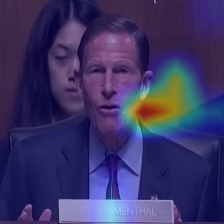

In [ ]:
NEW_VIDEO_FILENAME = "Screen Recording 2026-04-21 142855.mp4" # Adjust if your filename is different
NEW_VIDEO_PATH = os.path.join("/content/drive/MyDrive/", NEW_VIDEO_FILENAME)

print("New video path set:", NEW_VIDEO_PATH)

# Create a dummy DataFrame for the new video to reuse existing processing logic
new_video_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "video_path": [NEW_VIDEO_PATH],
    "label": ["UNKNOWN"], # Placeholder
    "target": [-1], # Placeholder
    "original": [None]
})

display(new_video_df.head())

# 1. Extract Frames for the New Video
new_video_id = Path(NEW_VIDEO_FILENAME).stem
new_frames_output_folder = os.path.join(FRAMES_DIR, new_video_id)

print(f"Extracting frames for {NEW_VIDEO_FILENAME}...")
frame_extracted = extract_frames(NEW_VIDEO_PATH, new_frames_output_folder, NUM_FRAMES)

if frame_extracted:
    print(f"Frames extracted to: {new_frames_output_folder}")
else:
    print(f"Failed to extract frames for {NEW_VIDEO_FILENAME}")

# 2. Extract Audio for the New Video
new_audio_path = os.path.join(AUDIO_DIR, f"{new_video_id}.wav")

print(f"Extracting audio for {NEW_VIDEO_FILENAME}...")
audio_extracted = extract_audio(NEW_VIDEO_PATH, new_audio_path)

if audio_extracted:
    print(f"Audio extracted to: {new_audio_path}")
else:
    print(f"Failed to extract audio for {NEW_VIDEO_FILENAME}")

# 3. Extract Visual Features for the New Video
print(f"Extracting visual features for {NEW_VIDEO_FILENAME}...")
new_visual_feature = extract_visual_feature(new_video_id)

new_visual_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_visual_feature):
    new_visual_records[0][f"v_{i}"] = value

new_visual_df = pd.DataFrame(new_visual_records)
display(new_visual_df.head())

# 4. Extract Audio Features for the New Video
print(f"Extracting audio features for {NEW_VIDEO_FILENAME}...")
new_audio_feature = extract_audio_feature(new_video_id)

new_audio_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_audio_feature):
    new_audio_records[0][f"a_{i}"] = value

new_audio_df = pd.DataFrame(new_audio_records)
display(new_audio_df.head())

# 5. Transcribe Audio and Extract Text Features for the New Video
print(f"Transcribing audio for {NEW_VIDEO_FILENAME}...")
new_transcript = transcribe_audio(new_video_id)

new_text_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "transcript": [new_transcript]
}).set_index("filename")

print("Transcript:", new_transcript)
display(new_text_df.head())

# 6. Combine All Features for the New Video
new_X_visual = new_visual_df[visual_cols].values
new_X_audio = new_audio_df[audio_cols].values
new_X_text = tfidf.transform([new_text_df.loc[NEW_VIDEO_FILENAME, "transcript"]]).toarray()

new_X = np.hstack([new_X_visual, new_X_audio, new_X_text])

print("Combined features shape for new video:", new_X.shape)

# 7. Scale and Select Features for the New Video
# Load scaler and selector
scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
selector = joblib.load(os.path.join(MODEL_DIR, "feature_selector.pkl"))

new_X_scaled = scaler.transform(new_X)
new_X_selected = selector.transform(new_X_scaled)

print("Scaled and selected features shape for new video:", new_X_selected.shape)

# 8. Load Best Model and Predict for the New Video
# Load the best model (LSTM)
lstm_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "final_lstm_model.keras"))

# Reshape for LSTM prediction
new_X_lstm = new_X_selected.reshape(1, new_X_selected.shape[1], 1)

new_lstm_probs = lstm_model.predict(new_X_lstm).ravel()
new_final_score = float(new_lstm_probs[0])

print(f"Prediction score for {NEW_VIDEO_FILENAME}: {new_final_score:.4f}")

# 9. Interpret Prediction
new_predicted_label = classify_final_score(new_final_score)
new_verdict = get_verdict(new_predicted_label, new_final_score)
new_explanation = get_explanation(new_predicted_label, new_final_score)

print("Predicted Label:", new_predicted_label)
print("Verdict:", new_verdict)
print("Explanation:", new_explanation)

# 10. Generate Grad-CAM for the New Video
new_frame_paths = sorted(list(Path(new_frames_output_folder).glob("*.jpg")))

if new_frame_paths:
    selected_frame = str(new_frame_paths[len(new_frame_paths) // 2])
    new_gradcam_output_path = os.path.join(EXPLAIN_DIR, f"{new_video_id}_gradcam_new_video.jpg")

    # Load the visual Grad-CAM model
    visual_gradcam_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras"))

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=new_gradcam_output_path,
            model=visual_gradcam_model
        )
        print("Grad-CAM image generated:", new_gradcam_output_path)
        display(Image(filename=new_gradcam_output_path))
    except Exception as e:
        print(f"Failed to generate Grad-CAM for {NEW_VIDEO_FILENAME}: {e}")
else:
    print("No frames found to generate Grad-CAM.")

New video path set: /content/drive/MyDrive/my2.mp4


,filename,video_path,label,target,original
0,my2.mp4,/content/drive/MyDrive/my2.mp4,UNKNOWN,-1,None


Extracting frames for my2.mp4...
Frames extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/frames/my2
Extracting audio for my2.mp4...
Audio extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/my2.wav
Extracting visual features for my2.mp4...


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,my2.mp4,0.059864,1.018467,0.142153,0.417605,0.009119,0.335589,0.052633,1.262263,0.19067,...,0.964407,1.342368,2.502553,0.008257,0.000403,0.919594,0.002039,0.017403,1.459862,0.044094


Extracting audio features for my2.mp4...


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,my2.mp4,-290.79071,115.540184,-7.419962,22.281208,-4.033728,4.035691,-11.912091,-6.527907,-12.423347,...,0.498168,0.488868,0.531286,0.584478,0.546848,0.688722,0.534834,0.519543,0.558753,0.579356


Transcribing audio for my2.mp4...
Transcript: 


,transcript
filename,
my2.mp4,


Combined features shape for new video: (1, 2020)
Scaled and selected features shape for new video: (1, 500)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
Prediction score for my2.mp4: 0.5023
Predicted Label: UNCERTAIN
Verdict: The model is not confident. Manual review is recommended.
Explanation: The final fake probability score is 0.5023, which lies between real and fake thresholds.
Grad-CAM image generated: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/my2_gradcam_new_video.jpg


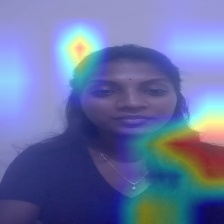

In [ ]:
NEW_VIDEO_FILENAME = "my2.mp4" # Adjust if your filename is different
NEW_VIDEO_PATH = os.path.join("/content/drive/MyDrive/", NEW_VIDEO_FILENAME)

print("New video path set:", NEW_VIDEO_PATH)

# Create a dummy DataFrame for the new video to reuse existing processing logic
new_video_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "video_path": [NEW_VIDEO_PATH],
    "label": ["UNKNOWN"], # Placeholder
    "target": [-1], # Placeholder
    "original": [None]
})

display(new_video_df.head())

# 1. Extract Frames for the New Video
new_video_id = Path(NEW_VIDEO_FILENAME).stem
new_frames_output_folder = os.path.join(FRAMES_DIR, new_video_id)

print(f"Extracting frames for {NEW_VIDEO_FILENAME}...")
frame_extracted = extract_frames(NEW_VIDEO_PATH, new_frames_output_folder, NUM_FRAMES)

if frame_extracted:
    print(f"Frames extracted to: {new_frames_output_folder}")
else:
    print(f"Failed to extract frames for {NEW_VIDEO_FILENAME}")

# 2. Extract Audio for the New Video
new_audio_path = os.path.join(AUDIO_DIR, f"{new_video_id}.wav")

print(f"Extracting audio for {NEW_VIDEO_FILENAME}...")
audio_extracted = extract_audio(NEW_VIDEO_PATH, new_audio_path)

if audio_extracted:
    print(f"Audio extracted to: {new_audio_path}")
else:
    print(f"Failed to extract audio for {NEW_VIDEO_FILENAME}")

# 3. Extract Visual Features for the New Video
print(f"Extracting visual features for {NEW_VIDEO_FILENAME}...")
new_visual_feature = extract_visual_feature(new_video_id)

new_visual_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_visual_feature):
    new_visual_records[0][f"v_{i}"] = value

new_visual_df = pd.DataFrame(new_visual_records)
display(new_visual_df.head())

# 4. Extract Audio Features for the New Video
print(f"Extracting audio features for {NEW_VIDEO_FILENAME}...")
new_audio_feature = extract_audio_feature(new_video_id)

new_audio_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_audio_feature):
    new_audio_records[0][f"a_{i}"] = value

new_audio_df = pd.DataFrame(new_audio_records)
display(new_audio_df.head())

# 5. Transcribe Audio and Extract Text Features for the New Video
print(f"Transcribing audio for {NEW_VIDEO_FILENAME}...")
new_transcript = transcribe_audio(new_video_id)

new_text_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "transcript": [new_transcript]
}).set_index("filename")

print("Transcript:", new_transcript)
display(new_text_df.head())

# 6. Combine All Features for the New Video
new_X_visual = new_visual_df[visual_cols].values
new_X_audio = new_audio_df[audio_cols].values
new_X_text = tfidf.transform([new_text_df.loc[NEW_VIDEO_FILENAME, "transcript"]]).toarray()

new_X = np.hstack([new_X_visual, new_X_audio, new_X_text])

print("Combined features shape for new video:", new_X.shape)

# 7. Scale and Select Features for the New Video
# Load scaler and selector
scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
selector = joblib.load(os.path.join(MODEL_DIR, "feature_selector.pkl"))

new_X_scaled = scaler.transform(new_X)
new_X_selected = selector.transform(new_X_scaled)

print("Scaled and selected features shape for new video:", new_X_selected.shape)

# 8. Load Best Model and Predict for the New Video
# Load the best model (LSTM)
lstm_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "final_lstm_model.keras"))

# Reshape for LSTM prediction
new_X_lstm = new_X_selected.reshape(1, new_X_selected.shape[1], 1)

new_lstm_probs = lstm_model.predict(new_X_lstm).ravel()
new_final_score = float(new_lstm_probs[0])

print(f"Prediction score for {NEW_VIDEO_FILENAME}: {new_final_score:.4f}")

# 9. Interpret Prediction
new_predicted_label = classify_final_score(new_final_score)
new_verdict = get_verdict(new_predicted_label, new_final_score)
new_explanation = get_explanation(new_predicted_label, new_final_score)

print("Predicted Label:", new_predicted_label)
print("Verdict:", new_verdict)
print("Explanation:", new_explanation)

# 10. Generate Grad-CAM for the New Video
new_frame_paths = sorted(list(Path(new_frames_output_folder).glob("*.jpg")))

if new_frame_paths:
    selected_frame = str(new_frame_paths[len(new_frame_paths) // 2])
    new_gradcam_output_path = os.path.join(EXPLAIN_DIR, f"{new_video_id}_gradcam_new_video.jpg")

    # Load the visual Grad-CAM model
    visual_gradcam_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras"))

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=new_gradcam_output_path,
            model=visual_gradcam_model
        )
        print("Grad-CAM image generated:", new_gradcam_output_path)
        display(Image(filename=new_gradcam_output_path))
    except Exception as e:
        print(f"Failed to generate Grad-CAM for {NEW_VIDEO_FILENAME}: {e}")
else:
    print("No frames found to generate Grad-CAM.")

New video path set: /content/drive/MyDrive/my3.mp4


,filename,video_path,label,target,original
0,my3.mp4,/content/drive/MyDrive/my3.mp4,UNKNOWN,-1,None


Extracting frames for my3.mp4...
Frames extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/frames/my3
Extracting audio for my3.mp4...
Audio extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/my3.wav
Extracting visual features for my3.mp4...


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,my3.mp4,0.0,0.287578,0.41102,0.488217,0.015382,0.075727,0.072154,1.500554,0.096928,...,0.010058,0.764158,1.874269,0.102094,0.01313,0.496447,0.00758,0.769445,0.091781,0.001622


Extracting audio features for my3.mp4...


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,my3.mp4,-541.058411,103.708641,41.705315,64.31604,16.04015,-2.786005,-6.509947,0.848891,6.020467,...,0.925812,0.850288,0.925537,0.956,0.880255,0.929733,0.931756,0.791987,0.622999,0.585146


Transcribing audio for my3.mp4...
Transcript: 


,transcript
filename,
my3.mp4,


Combined features shape for new video: (1, 2020)
Scaled and selected features shape for new video: (1, 500)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
Prediction score for my3.mp4: 0.5009
Predicted Label: UNCERTAIN
Verdict: The model is not confident. Manual review is recommended.
Explanation: The final fake probability score is 0.5009, which lies between real and fake thresholds.
Grad-CAM image generated: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/my3_gradcam_new_video.jpg


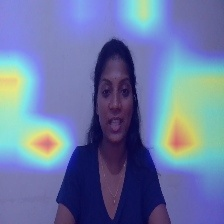

In [ ]:
NEW_VIDEO_FILENAME = "my3.mp4" # Adjust if your filename is different
NEW_VIDEO_PATH = os.path.join("/content/drive/MyDrive/", NEW_VIDEO_FILENAME)

print("New video path set:", NEW_VIDEO_PATH)

# Create a dummy DataFrame for the new video to reuse existing processing logic
new_video_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "video_path": [NEW_VIDEO_PATH],
    "label": ["UNKNOWN"], # Placeholder
    "target": [-1], # Placeholder
    "original": [None]
})

display(new_video_df.head())

# 1. Extract Frames for the New Video
new_video_id = Path(NEW_VIDEO_FILENAME).stem
new_frames_output_folder = os.path.join(FRAMES_DIR, new_video_id)

print(f"Extracting frames for {NEW_VIDEO_FILENAME}...")
frame_extracted = extract_frames(NEW_VIDEO_PATH, new_frames_output_folder, NUM_FRAMES)

if frame_extracted:
    print(f"Frames extracted to: {new_frames_output_folder}")
else:
    print(f"Failed to extract frames for {NEW_VIDEO_FILENAME}")

# 2. Extract Audio for the New Video
new_audio_path = os.path.join(AUDIO_DIR, f"{new_video_id}.wav")

print(f"Extracting audio for {NEW_VIDEO_FILENAME}...")
audio_extracted = extract_audio(NEW_VIDEO_PATH, new_audio_path)

if audio_extracted:
    print(f"Audio extracted to: {new_audio_path}")
else:
    print(f"Failed to extract audio for {NEW_VIDEO_FILENAME}")

# 3. Extract Visual Features for the New Video
print(f"Extracting visual features for {NEW_VIDEO_FILENAME}...")
new_visual_feature = extract_visual_feature(new_video_id)

new_visual_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_visual_feature):
    new_visual_records[0][f"v_{i}"] = value

new_visual_df = pd.DataFrame(new_visual_records)
display(new_visual_df.head())

# 4. Extract Audio Features for the New Video
print(f"Extracting audio features for {NEW_VIDEO_FILENAME}...")
new_audio_feature = extract_audio_feature(new_video_id)

new_audio_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_audio_feature):
    new_audio_records[0][f"a_{i}"] = value

new_audio_df = pd.DataFrame(new_audio_records)
display(new_audio_df.head())

# 5. Transcribe Audio and Extract Text Features for the New Video
print(f"Transcribing audio for {NEW_VIDEO_FILENAME}...")
new_transcript = transcribe_audio(new_video_id)

new_text_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "transcript": [new_transcript]
}).set_index("filename")

print("Transcript:", new_transcript)
display(new_text_df.head())

# 6. Combine All Features for the New Video
new_X_visual = new_visual_df[visual_cols].values
new_X_audio = new_audio_df[audio_cols].values
new_X_text = tfidf.transform([new_text_df.loc[NEW_VIDEO_FILENAME, "transcript"]]).toarray()

new_X = np.hstack([new_X_visual, new_X_audio, new_X_text])

print("Combined features shape for new video:", new_X.shape)

# 7. Scale and Select Features for the New Video
# Load scaler and selector
scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
selector = joblib.load(os.path.join(MODEL_DIR, "feature_selector.pkl"))

new_X_scaled = scaler.transform(new_X)
new_X_selected = selector.transform(new_X_scaled)

print("Scaled and selected features shape for new video:", new_X_selected.shape)

# 8. Load Best Model and Predict for the New Video
# Load the best model (LSTM)
lstm_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "final_lstm_model.keras"))

# Reshape for LSTM prediction
new_X_lstm = new_X_selected.reshape(1, new_X_selected.shape[1], 1)

new_lstm_probs = lstm_model.predict(new_X_lstm).ravel()
new_final_score = float(new_lstm_probs[0])

print(f"Prediction score for {NEW_VIDEO_FILENAME}: {new_final_score:.4f}")

# 9. Interpret Prediction
new_predicted_label = classify_final_score(new_final_score)
new_verdict = get_verdict(new_predicted_label, new_final_score)
new_explanation = get_explanation(new_predicted_label, new_final_score)

print("Predicted Label:", new_predicted_label)
print("Verdict:", new_verdict)
print("Explanation:", new_explanation)

# 10. Generate Grad-CAM for the New Video
new_frame_paths = sorted(list(Path(new_frames_output_folder).glob("*.jpg")))

if new_frame_paths:
    selected_frame = str(new_frame_paths[len(new_frame_paths) // 2])
    new_gradcam_output_path = os.path.join(EXPLAIN_DIR, f"{new_video_id}_gradcam_new_video.jpg")

    # Load the visual Grad-CAM model
    visual_gradcam_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras"))

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=new_gradcam_output_path,
            model=visual_gradcam_model
        )
        print("Grad-CAM image generated:", new_gradcam_output_path)
        display(Image(filename=new_gradcam_output_path))
    except Exception as e:
        print(f"Failed to generate Grad-CAM for {NEW_VIDEO_FILENAME}: {e}")
else:
    print("No frames found to generate Grad-CAM.")